# E57 · Watching single molecules move: diffusion states, localisation error and anomalous diffusion in single-particle tracking

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: single-molecule tracks of the transcription factor RARA (retinoic acid receptor α, HaloTag-labelled) and of a free HaloTag-NLS control in the nuclei of living human U2OS cells, 7.48 ms per frame, 160 nm pixels, from the example data of the saSPT package (Heckert et al. 2022; 2 RARA cells, 11 control cells, 81k localisations). Sections 1-3 and the checks in 6-7 use simulations at the same scales |
| **You will learn** | Brownian motion in 2-D and the **mean squared displacement**, and why fitting a line to an MSD curve is a poor estimator · **static localisation error** and **motion blur** make successive displacements negatively correlated: the exact track likelihood is Gaussian with a **tridiagonal (MA(1)) covariance** · an exact, scan-free likelihood from the **sine-transform eigenbasis** of that covariance · the **$D$-$\sigma$ trade-off** of short tracks · a Spot-On-style **mixture of diffusive states** (bound vs free) with state-dependent track loss (**out-of-focus bias**), 2 vs 3 states by LOO, and a **hierarchy across cells** · a **hidden Markov model** of binding and unbinding inside tracks whose forward algorithm carries the localisation error (a GPB1 filter in `scan`) - and why the textbook HMM cannot tell a bound molecule from noise · **fractional Brownian motion**: Toeplitz covariances, the anomalous exponent $\alpha = 2H$, and how localisation error **fakes subdiffusion** |

## Following one molecule at a time

A transcription factor has to find its binding sites among billions of base pairs of DNA. How
long does it stay bound? What fraction of the molecules are bound at any moment? How fast do
the free ones move, and does the crowded nucleus slow them down? Since about 2010 these
questions are answered by **single-particle tracking (SPT)**: tag the protein with a bright dye,
excite so few molecules that each appears as an isolated spot, fit each spot's centre to a few
tens of nanometres, and link the centres from frame to frame into **tracks**. A bound molecule
jitters in place (with the chromatin it sits on); a free one jumps hundreds of nanometres per
frame. The statistics of those jumps are the data.

They are treacherous data. Every position carries a **localisation error** of 20-40 nm, which
for a bound molecule is as large as its real motion. The camera integrates each spot over the
exposure, so a moving molecule is **blurred**. Tracks are short - a molecule bleaches or
leaves the thin focal plane after a handful of frames, and fast molecules leave sooner. The
standard workflow (compute a mean squared displacement curve, fit a straight line) mishandles
all three. This notebook builds the exact likelihood instead and then uses it four ways: for
single tracks, for a population of molecules in several states, for molecules that switch
state inside a track, and to ask whether a motion is anomalous.

## The plan

1. Brownian motion, localisation error and motion blur
2. The exact likelihood of a track, and a basis that makes it free
3. One track at a time: the MSD fit versus the likelihood
4. Data: RARA and a free control in living nuclei
5. A population of states: bound and free (Spot-On style)
6. Switching inside a track: a hidden Markov model that knows about localisation error
7. Is it anomalous? Fractional Brownian motion and fake subdiffusion

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr
from scipy import stats
from scipy.special import expit, logsumexp

from pymc_challenges import data

RANDOM_SEED = 57
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="The effect of Potentials")
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
JAX = {"backend": "jax", "gradient_backend": "jax"}    # for the scan / Cholesky models (2-3x faster)
DT = 0.00748                                          # frame interval of the data (s)
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")


def fit(model, label, **kw):
    """Sample with nutpie, print time, divergences and worst r_hat / ESS of the named variables."""
    t0 = time.time()
    idata = pm.sample(model=model, random_seed=RANDOM_SEED, progressbar=False, **kw)
    names = kw.get("var_names") or list(idata.posterior.data_vars)
    rh = max(float(az.rhat(idata.posterior[v]).max()) for v in names)
    es = min(float(az.ess(idata.posterior[v]).min()) for v in names)
    print(f"{label}: {time.time() - t0:.0f} s, divergences {int(idata.sample_stats['diverging'].sum())}, "
          f"max r_hat {rh:.3f}, min ESS {es:.0f}")
    return idata

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## 1 · Brownian motion, localisation error and motion blur

A freely diffusing molecule in two dimensions takes independent Gaussian steps: over a time
$\Delta t$ each coordinate moves by $\mathcal N(0, 2D\Delta t)$, where $D$ is the **diffusion
coefficient** (µm²/s). Its **mean squared displacement** grows linearly,
$\text{MSD}(\tau) = \langle |r(t+\tau) - r(t)|^2\rangle = 4D\tau$ in 2-D, and the MSD curve of a
track is the standard summary.

Two things stand between the molecule and the recorded positions.

- **Static localisation error.** Each recorded position is the true one plus $\mathcal N(0,
  \sigma^2)$ per coordinate, independently from frame to frame; $\sigma$ is set by the number of
  photons and the background (typically 20-40 nm).
- **Motion blur.** The camera records the *average* position over the exposure, not a snapshot.
  Averaging a Brownian path over a window shrinks its variance. Berglund (2010) summarised any
  exposure profile by one number, $R$ ($R = 1/6$ for a continuous exposure over the whole frame,
  $R \approx 0$ for a short stroboscopic flash).

For the observed displacements $\Delta_k = y_{k+1} - y_k$ of one coordinate this gives (Berglund
2010, eq. 7; Michalet 2010)

$$\operatorname{Var}(\Delta_k) = 2D\Delta t\,(1 - 2R) + 2\sigma^2, \qquad
  \operatorname{Cov}(\Delta_k, \Delta_{k+1}) = 2D\Delta t\,R - \sigma^2, \qquad
  \operatorname{Cov}(\Delta_k, \Delta_{k+j}) = 0 \ (j \ge 2).$$

The same error $e_{k+1}$ enters $\Delta_k$ with a plus sign and $\Delta_{k+1}$ with a minus sign,
so **successive displacements are negatively correlated** - a jump "out" by error is followed by
a jump "back". The MSD curve becomes $4D\tau + 4\sigma^2 - 8DR\Delta t$: a line with an offset.
We simulate this at the scales of the data below: a bound molecule ($D = 0.03$ µm²/s), a free
one ($D = 3$ µm²/s), $\sigma = 30$ nm, $\Delta t = 7.48$ ms. The simulator follows the true path
on 30 sub-steps per frame and averages it over the exposure.

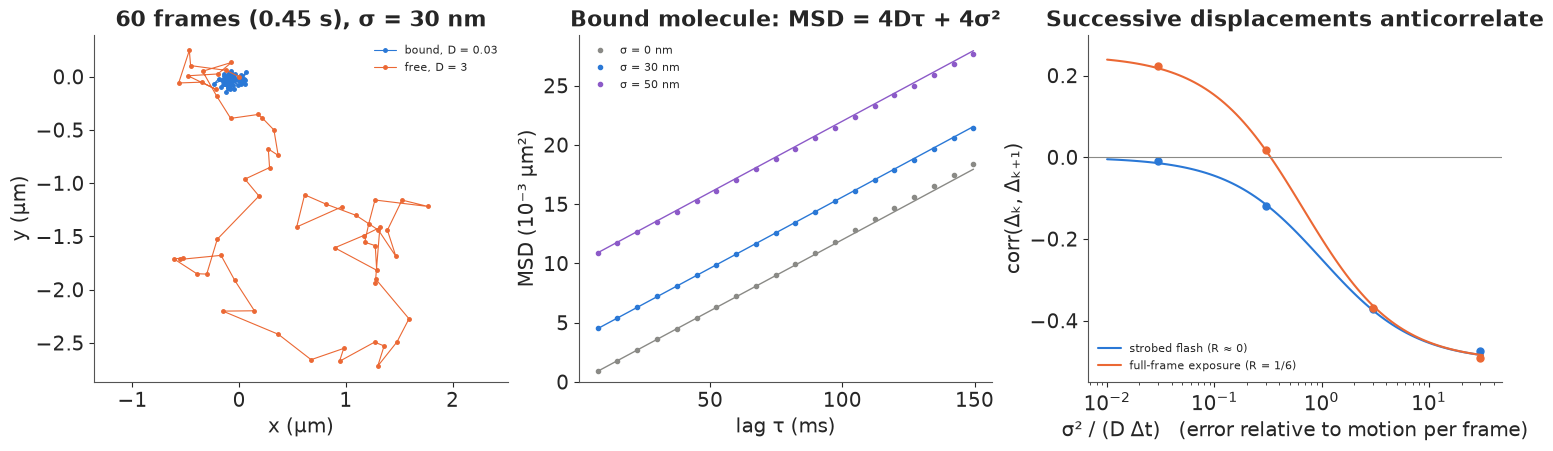

In [2]:
def simulate_track(n, D, sigma, rng, dt=DT, exposure=1.0, sub=30):
    """n observed 2-D positions: Brownian path averaged over `exposure` x dt of each frame + error."""
    h = dt / sub
    path = np.cumsum(rng.normal(0, np.sqrt(2 * D * h), size=(n * sub, 2)), axis=0).reshape(n, sub, 2)
    m = max(1, int(round(exposure * sub)))
    return path[:, :m].mean(axis=1) + rng.normal(0, sigma, size=(n, 2))


def msd_curve(track, max_lag):
    return np.array([np.mean(np.sum((track[k:] - track[:-k]) ** 2, axis=1)) for k in range(1, max_lag + 1)])


def rho1(D, sigma, R, dt=DT):
    """Lag-1 correlation of successive displacements (one coordinate)."""
    return (2 * D * dt * R - sigma**2) / (2 * D * dt * (1 - 2 * R) + 2 * sigma**2)


rng1 = np.random.default_rng(1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ax = axes[0]
for D, col, lab in [(0.03, BLUE, "bound, D = 0.03"), (3.0, ORANGE, "free, D = 3")]:
    tr = simulate_track(60, D, 0.03, rng1, exposure=0.03)
    ax.plot(tr[:, 0] - tr[0, 0], tr[:, 1] - tr[0, 1], "-o", ms=2.5, lw=0.8, color=col, label=lab)
ax.set(xlabel="x (µm)", ylabel="y (µm)", title="60 frames (0.45 s), σ = 30 nm")
ax.set_aspect("equal", adjustable="datalim")
ax.legend(fontsize=8)

ax = axes[1]
lags = np.arange(1, 21)
for sigma, col in [(0.0, GREY), (0.03, BLUE), (0.05, PURPLE)]:
    m = np.mean([msd_curve(simulate_track(200, 0.03, sigma, rng1, exposure=0.03), 20)
                 for _ in range(200)], axis=0)
    ax.plot(lags * DT * 1e3, m * 1e3, "o", ms=3, color=col, label=f"σ = {sigma * 1e3:.0f} nm")
    ax.plot(lags * DT * 1e3, (4 * 0.03 * lags * DT + 4 * sigma**2) * 1e3, lw=1, color=col)
ax.set(xlabel="lag τ (ms)", ylabel="MSD (10⁻³ µm²)", title="Bound molecule: MSD = 4Dτ + 4σ²",
       ylim=(0, None))
ax.legend(fontsize=8)

ax = axes[2]
x_grid = np.logspace(-2, 1.5, 100)                       # sigma^2 / (D dt)
for R, col, lab, expo in [(0.0, BLUE, "strobed flash (R ≈ 0)", 0.03), (1 / 6, ORANGE, "full-frame exposure (R = 1/6)", 1.0)]:
    ax.plot(x_grid, rho1(1.0, np.sqrt(x_grid * DT), R), color=col, label=lab)
    for xv in [0.03, 0.3, 3, 30]:
        sig = np.sqrt(xv * 1.0 * DT)
        d = np.concatenate([np.diff(simulate_track(400, 1.0, sig, rng1, exposure=expo), axis=0)
                            for _ in range(25)])
        ax.plot(xv, np.corrcoef(d[:-1, 0], d[1:, 0])[0, 1], "o", color=col, ms=5)
ax.axhline(0, color=GREY, lw=0.8)
ax.set(xscale="log", xlabel="σ² / (D Δt)   (error relative to motion per frame)",
       ylabel="corr(Δₖ, Δₖ₊₁)", title="Successive displacements anticorrelate", ylim=(-0.55, 0.3))
ax.legend(fontsize=8, loc="lower left");

**Left:** in 60 frames the bound molecule stays within about 0.1 µm, while the free one wanders
3 µm. **Middle:** averaged over 200 simulated tracks, the MSD of the bound molecule is a straight
line whose intercept is $4\sigma^2$: with $\sigma = 30$ nm the offset equals the diffusive growth
over $\sigma^2/D = 30$ ms, four frames. For a bound molecule at 30-50 nm error, most of the first
MSD points is error. **Right:** the lag-1 correlation of successive displacements (lines: the
formula; dots: simulations) depends on one number, the error relative to the motion per frame,
$\sigma^2 / (D\Delta t)$. With a short flash it runs from 0 (motion dominates) to $-1/2$ (error
dominates). With full-frame exposure blur adds a *positive* correlation of up to $+1/4$ (an averaged
path is smoother), and the two curves merge once error dominates. For the data below a bound
molecule has $\sigma^2/(D\Delta t) \approx 4$ (correlation about $-0.4$), a free one about 0.04.

## 2 · The exact likelihood of a track, and a basis that makes it free

Stack the $m = n - 1$ displacements of one coordinate into a vector $\Delta$. It is Gaussian with
mean zero and the **tridiagonal Toeplitz** covariance $\Sigma$ above: diagonal $a = 2D\Delta t(1-2R)
+ 2\sigma^2$, off-diagonal $b = 2D\Delta tR - \sigma^2$. That is the covariance of a moving average
of order one (MA(1)), and $x$ and $y$ are independent. Fitting a line to an MSD curve throws most
of this structure away (and treats strongly correlated MSD points as independent); the
likelihood uses all of it.

One could hand $\Sigma$ to `pm.MvNormal`, one track at a time. There is a much better way. **Every
tridiagonal Toeplitz matrix has the same eigenvectors**, the discrete sine basis
$Q_{ij} = \sqrt{2/(m+1)}\,\sin(ij\pi/(m+1))$, with eigenvalues $a + 2b\cos(j\pi/(m+1))$. So if we
rotate each track once, in NumPy, $u = Q\Delta$, the $m$ coefficients are **independent**
Gaussians with variances

$$v_j = 2D\Delta t\,\big[1 - 2R(1 - c_j)\big] + 2\sigma^2 (1 - c_j), \qquad c_j = \cos\frac{j\pi}{m+1}.$$

This is the likelihood of a track as a plain `pm.Normal` on precomputed numbers: no matrices, no
`scan`, any number of tracks of any lengths in one vector. It also reads like a spectrum: slow
modes ($c_j \approx 1$) have variance $2D\Delta t$ and **see only diffusion**; fast modes ($c_j
\approx -1$) have variance $2D\Delta t(1-4R) + 4\sigma^2$ and **carry the localisation error**.
A track of $m$ displacements has only $m$ modes to split between the two - the root of the
$D$-$\sigma$ trade-off below. And one more consequence: $\sigma^2$ and $R$ enter only through
$\sigma^2 - 2DR\Delta t$, so **blur and localisation error cannot be separated from tracks alone**
- $\sigma$ fitted with $R = 0$ is an *effective* error (smaller than the true one when there is
blur). We check the rotation against the dense Gaussian first.

In [3]:
def dst_basis(m):
    """Eigenvectors (rows) and cosines of every m x m tridiagonal Toeplitz matrix."""
    j = np.arange(1, m + 1)
    return np.sqrt(2 / (m + 1)) * np.sin(np.outer(j, j) * np.pi / (m + 1)), np.cos(j * np.pi / (m + 1))


def mode_var(D, sigma, c, R=0.0, dt=DT):
    return 2 * D * dt * (1 - 2 * R * (1 - c)) + 2 * sigma**2 * (1 - c)


m_chk, D_chk, s_chk, R_chk = 12, 0.5, 0.03, 1 / 6
Sigma = (np.diag(np.full(m_chk, 2 * D_chk * DT * (1 - 2 * R_chk) + 2 * s_chk**2))
         + (2 * D_chk * DT * R_chk - s_chk**2) * (np.eye(m_chk, k=1) + np.eye(m_chk, k=-1)))
Q, c = dst_basis(m_chk)
x_chk = rng.multivariate_normal(np.zeros(m_chk), Sigma)
print(f"dense MvNormal logpdf {stats.multivariate_normal(np.zeros(m_chk), Sigma).logpdf(x_chk):.10f}")
print(f"sine-basis sum       {stats.norm(0, np.sqrt(mode_var(D_chk, s_chk, c, R_chk))).logpdf(Q @ x_chk).sum():.10f}")


def pack_tracks(tracks, cap=None):
    """Rotate every track: returns summed squared coefficients (x and y), cosines and track index."""
    z2, cc, idx = [], [], []
    for i, t in enumerate(tracks):
        d = np.diff(t[:cap], axis=0)
        Qm, cm = dst_basis(len(d))
        z2.append(((Qm @ d) ** 2).sum(axis=1))
        cc.append(cm)
        idx.append(np.full(len(d), i))
    return np.concatenate(z2), np.concatenate(cc), np.concatenate(idx)

dense MvNormal logpdf 14.7909033297
sine-basis sum       14.7909033297


Because $x$ and $y$ share the variance $v_j$, each mode contributes a $\chi^2$ with two degrees of
freedom: $\log p = -\log(2\pi v_j) - (u_{x,j}^2 + u_{y,j}^2)/(2 v_j)$. The figure shows the
mode variances for a bound molecule and the empirical "periodogram" (the squared coefficients,
averaged over 500 simulated tracks of 30 positions).

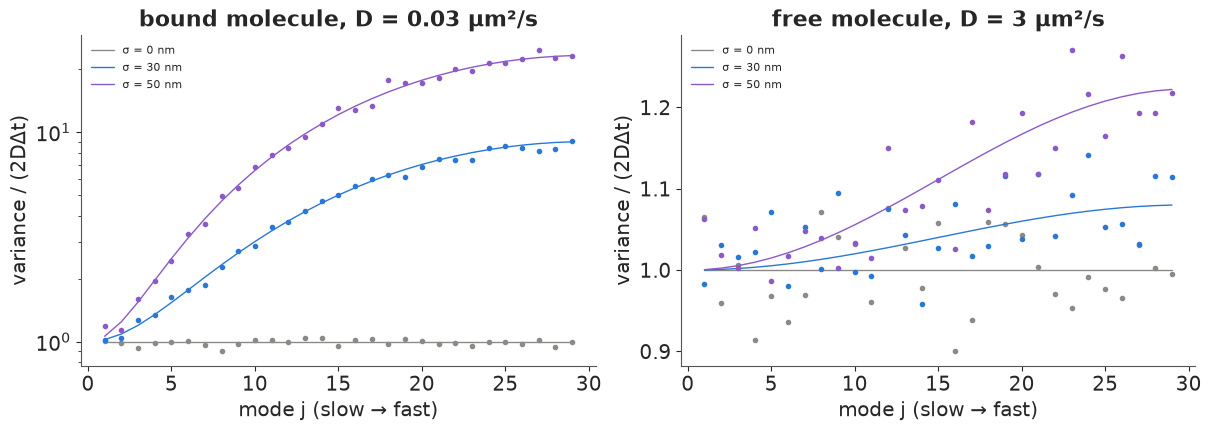

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
m30 = 29
Q30, c30 = dst_basis(m30)
jj = np.arange(1, m30 + 1)
for ax, D, title in [(axes[0], 0.03, "bound molecule, D = 0.03 µm²/s"), (axes[1], 3.0, "free molecule, D = 3 µm²/s")]:
    for sigma, col in [(0.0, GREY), (0.03, BLUE), (0.05, PURPLE)]:
        sims = np.array([np.diff(simulate_track(30, D, sigma, rng1, exposure=0.03), axis=0) for _ in range(500)])
        pg = np.mean((np.einsum("ij,njk->nik", Q30, sims) ** 2).mean(axis=2), axis=0)
        ax.plot(jj, pg / (2 * D * DT), "o", ms=3, color=col)
        ax.plot(jj, mode_var(D, sigma, c30) / (2 * D * DT), color=col, lw=1, label=f"σ = {sigma * 1e3:.0f} nm")
    ax.set(xlabel="mode j (slow → fast)", ylabel="variance / (2DΔt)", title=title, yscale="log" if D < 1 else "linear")
    ax.legend(fontsize=8)

The dots (simulation) sit on the lines (formula). For the bound molecule the fast modes carry
9 times ($\sigma = 30$ nm) and 23 times ($\sigma = 50$ nm) the variance of the slow ones: the slow
end of the spectrum is where $D$ is measured, and a track needs enough slow modes - enough length -
for that. For the free molecule the error lifts the fast modes by at most 8% and 22%, within the
scatter of 500 tracks: at $D = 3$ µm²/s localisation error barely matters and $\sigma$ will be hard
to learn from free molecules.

## 3 · One track at a time: the MSD fit versus the likelihood

First a single short track (11 positions, a typical length in the data) and a long one (101
positions) of the same bound molecule, $D = 0.03$ µm²/s and $\sigma = 30$ nm, each with its own
$D$ and $\sigma$. Priors: $\log D \sim \mathcal N(\log 0.1, 2)$ (from 0.002 to 5 µm²/s within
two sd, bound to free), $\log\sigma \sim \mathcal N(\log 0.03, 1)$ (a factor of 2.7 around 30 nm).

11 positions: 2 s, divergences 0, max r_hat 1.003, min ESS 959


101 positions: 0 s, divergences 0, max r_hat 1.001, min ESS 2222
 11 positions: D 89% interval 0.037-0.255 µm²/s, sigma 7-45 nm, corr(log D, log sigma) = -0.57
101 positions: D 89% interval 0.015-0.039 µm²/s, sigma 27-34 nm, corr(log D, log sigma) = -0.50


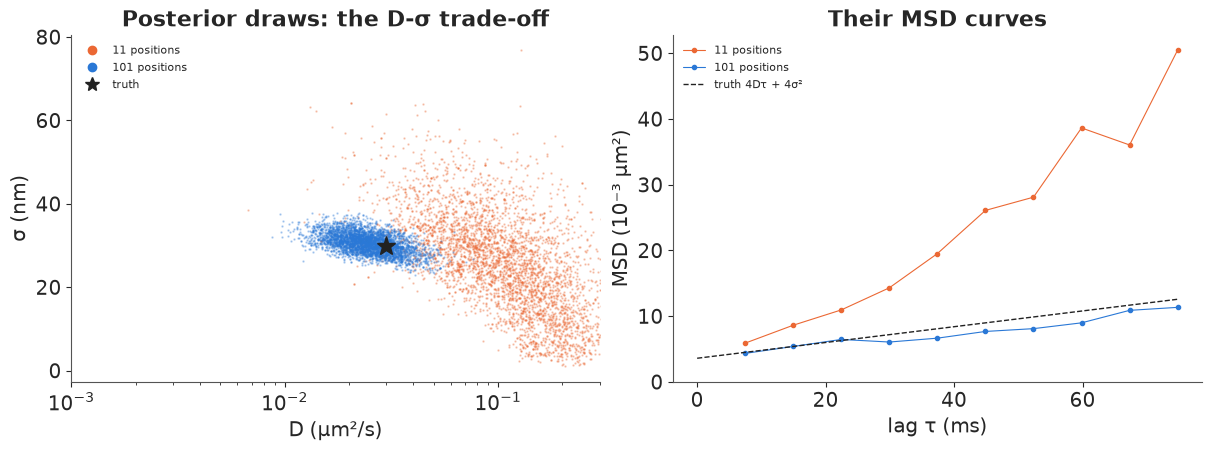

In [5]:
def per_track_model(tracks, R=0.0):
    z2, cc, idx = pack_tracks(tracks)
    with pm.Model(coords={"track": np.arange(len(tracks))}) as model:
        logD = pm.Normal("logD", np.log(0.1), 2.0, dims="track")
        log_sigma = pm.Normal("log_sigma", np.log(0.03), 1.0, dims="track")
        v = mode_var(pt.exp(logD)[idx], pt.exp(log_sigma)[idx], cc, R)
        pm.Potential("lik", pt.sum(-pt.log(2 * np.pi * v) - z2 / (2 * v)))
    return model


rng3 = np.random.default_rng(3)
track_short = simulate_track(11, 0.03, 0.03, rng3, exposure=0.03)
track_long = simulate_track(101, 0.03, 0.03, rng3, exposure=0.03)
idata_short = fit(per_track_model([track_short]), "11 positions")
idata_long = fit(per_track_model([track_long]), "101 positions")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ax = axes[0]
for idata_, col, lab in [(idata_short, ORANGE, "11 positions"), (idata_long, BLUE, "101 positions")]:
    ax.plot(np.exp(idata_.posterior["logD"].values.ravel()), np.exp(idata_.posterior["log_sigma"].values.ravel()) * 1e3,
            ".", ms=1.5, alpha=0.3, color=col, label=lab)
ax.plot(0.03, 30, "*", ms=14, color=INK, label="truth")
ax.set(xscale="log", xlabel="D (µm²/s)", ylabel="σ (nm)", title="Posterior draws: the D-σ trade-off", xlim=(1e-3, 0.3))
ax.legend(handles=[plt.Line2D([], [], ls="", marker="o", color=ORANGE, label="11 positions"),
                   plt.Line2D([], [], ls="", marker="o", color=BLUE, label="101 positions"),
                   plt.Line2D([], [], ls="", marker="*", ms=10, color=INK, label="truth")], fontsize=8)
ax = axes[1]
for tr, col, lab in [(track_short, ORANGE, "11 positions"), (track_long, BLUE, "101 positions")]:
    mm = msd_curve(tr, min(10, len(tr) - 1))
    ax.plot(np.arange(1, len(mm) + 1) * DT * 1e3, mm * 1e3, "o-", ms=3, lw=0.8, color=col, label=lab)
lg = np.arange(0, 11)
ax.plot(lg * DT * 1e3, (4 * 0.03 * lg * DT + 4 * 0.03**2) * 1e3, "--", color=INK, lw=1, label="truth 4Dτ + 4σ²")
ax.set(xlabel="lag τ (ms)", ylabel="MSD (10⁻³ µm²)", title="Their MSD curves", ylim=(0, None))
ax.legend(fontsize=8)
for lab, idata_ in [("11", idata_short), ("101", idata_long)]:
    Dd = np.exp(idata_.posterior["logD"].values.ravel())
    sd = np.exp(idata_.posterior["log_sigma"].values.ravel())
    print(f"{lab:>3} positions: D 89% interval {np.quantile(Dd, 0.055):.3f}-{np.quantile(Dd, 0.945):.3f} µm²/s, "
          f"sigma {np.quantile(sd, 0.055) * 1e3:.0f}-{np.quantile(sd, 0.945) * 1e3:.0f} nm, "
          f"corr(log D, log sigma) = {np.corrcoef(np.log(Dd), np.log(sd))[0, 1]:.2f}")

**Left:** the posterior of the long track is a small blob around the truth. The short track's is a
long diagonal ridge (correlation $-0.57$ between $\log D$ and $\log\sigma$): a bit more diffusion and
a bit less error explain ten displacements equally well. The data pin down roughly $2D\Delta t +
2\sigma^2$, not the split. This particular short track also happens to wander more than a
typical one (its MSD curve, **right**, climbs far above the truth), so its 89% interval for $D$,
0.037-0.255 µm²/s, misses the true 0.03. That is what 89% intervals do about one time in nine; the
200-track check below measures how often. Its $\sigma$ interval (7-45 nm) says the track itself
carries little information on the error. The long track gives $D$ 0.015-0.039 and $\sigma$
27-34 nm.

### Two hundred short tracks: three estimators

Now 200 tracks of 11 positions each, with $D$ spread log-normally around 0.05 µm²/s (from bound
to slow) and $\sigma = 30$ nm, all fitted in **one** model (each track its own $D$ and $\sigma$;
400 parameters, one vector of modes). We compare the posterior median of $D$ with two MSD
estimators in everyday use: $\hat D_1 = \text{MSD}(\Delta t)/4\Delta t$ (the first point alone,
which ignores the error) and a least-squares line through the first four MSD points,
$\text{MSD} = 4D\tau + \text{offset}$ (which allows for it; Michalet 2010 shows that few points
are best).

200 tracks, 400 parameters: 2 s, divergences 0, max r_hat 1.008, min ESS 1768
89% intervals covering the true D: 91%
       MSD(1)/4dt: median ratio to truth  2.97, non-positive   0%, rms log error (positive ones) 1.43
 4-point MSD line: median ratio to truth  0.81, non-positive  13%, rms log error (positive ones) 1.06
 posterior median: median ratio to truth  1.08, non-positive   0%, rms log error (positive ones) 0.66


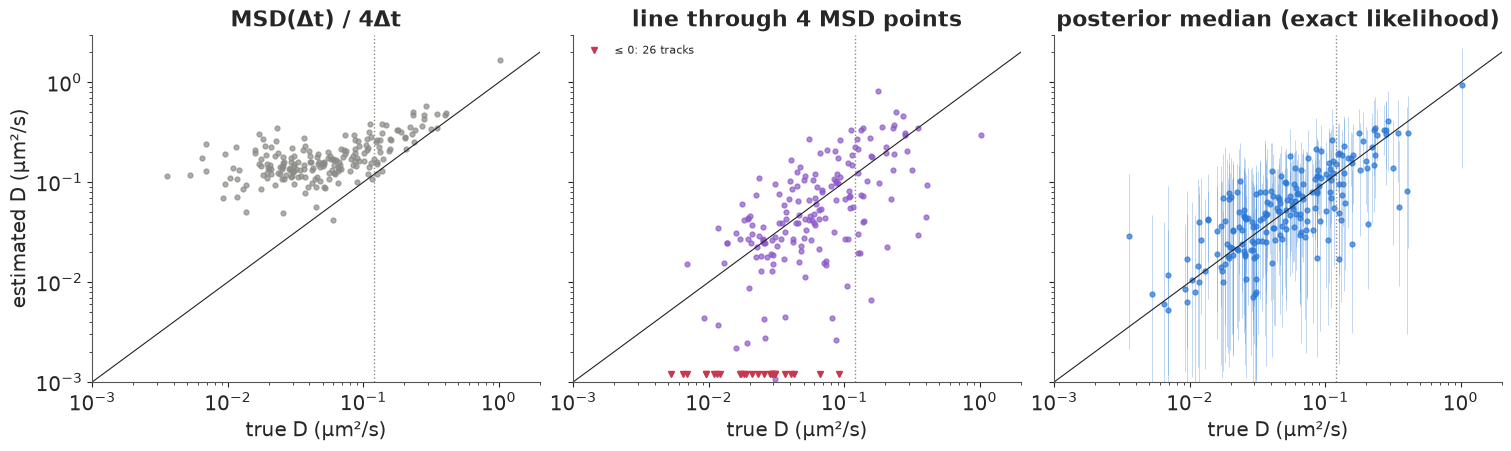

In [6]:
rng3b = np.random.default_rng(33)
n_sim = 200
D_true = np.exp(rng3b.normal(np.log(0.05), 1.0, n_sim))
sim_tracks = [simulate_track(11, d, 0.03, rng3b, exposure=0.03) for d in D_true]
idata_200 = fit(per_track_model(sim_tracks), "200 tracks, 400 parameters")

D_bayes = np.exp(idata_200.posterior["logD"].median(("chain", "draw")).values)
lo, hi = np.exp(idata_200.posterior["logD"].quantile([0.055, 0.945], dim=("chain", "draw")).values)
D_msd1 = np.array([msd_curve(t, 1)[0] / (4 * DT) for t in sim_tracks])
X_ls = np.c_[4 * DT * np.arange(1, 5), np.ones(4)]
D_line = np.array([np.linalg.lstsq(X_ls, msd_curve(t, 4), rcond=None)[0][0] for t in sim_tracks])
print(f"89% intervals covering the true D: {np.mean((D_true > lo) & (D_true < hi)):.0%}")
for lab, est in [("MSD(1)/4dt", D_msd1), ("4-point MSD line", D_line), ("posterior median", D_bayes)]:
    ok = est > 0
    print(f"{lab:>17}: median ratio to truth {np.median(est / D_true):5.2f}, "
          f"non-positive {np.mean(~ok):4.0%}, rms log error (positive ones) "
          f"{np.sqrt(np.mean(np.log(est[ok] / D_true[ok]) ** 2)):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharex=True, sharey=True)
for ax, (lab, est, col) in zip(axes, [("MSD(Δt) / 4Δt", D_msd1, GREY), ("line through 4 MSD points", D_line, PURPLE),
                                      ("posterior median (exact likelihood)", D_bayes, BLUE)]):
    ok = est > 0
    ax.plot(D_true[ok], est[ok], "o", ms=3.5, color=col, alpha=0.7)
    ax.plot(D_true[~ok], np.full((~ok).sum(), 1.2e-3), "v", ms=4, color=RED, label=f"≤ 0: {(~ok).sum()} tracks")
    if lab.startswith("posterior"):
        ax.vlines(D_true, lo, hi, color=col, lw=0.5, alpha=0.4)
    ax.plot([1e-3, 3], [1e-3, 3], color=INK, lw=0.8)
    ax.axvline(0.03**2 / DT, color=GREY, ls=":", lw=1)
    ax.set(xscale="log", yscale="log", xlabel="true D (µm²/s)", title=lab, xlim=(1e-3, 2), ylim=(1e-3, 3))
    if (~ok).any():
        ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("estimated D (µm²/s)");

- **MSD$(\Delta t)/4\Delta t$** estimates $D + \sigma^2/\Delta t$, not $D$: for every bound molecule
  it reports about 0.1-0.2 µm²/s whatever the truth (median 3 times too large). The dotted line
  marks $D = \sigma^2/\Delta t = 0.12$ µm²/s, where the error per frame equals the motion; below it
  this estimator measures the microscope, not the molecule.
- **The four-point line** removes the offset on average (median ratio 0.8) but is wildly noisy:
  26 of 200 tracks (13%) get a zero or negative $D$, and the rest scatter over two decades
  (rms error 1.06 in $\log D$). Four correlated MSD points of an 11-position track are not four
  independent measurements.
- **The exact likelihood** is close to unbiased (median ratio 1.08), has the smallest error (rms
  0.66 in $\log D$), never goes negative, and its 89% intervals cover the truth for 91% of
  tracks - honest uncertainty, wide where the track is short and the molecule slow.

All 200 tracks with 400 parameters sampled in a couple of seconds, because the likelihood is one
vectorised `Normal` over precomputed modes.

## 4 · Data: RARA and a free control in living nuclei

The saSPT package (Heckert, Dahal, Tjian & Darzacq 2022) ships two real datasets as examples:
tracks of **RARA-HaloTag**, a nuclear receptor that binds DNA, and of **HaloTag-NLS**, the bare tag
with a nuclear localisation signal, which has nothing to bind and should diffuse freely. Both
were imaged in the nuclei of U2OS cells at 7.48 ms per frame with 160 nm pixels, and the package's
settings give a focal depth of 0.7 µm. Molecules are photoactivated sparsely, so each region
(one nucleus) contributes thousands of short tracks. We keep two RARA nuclei and all eleven
control nuclei, frames from 1000 on (as the package's examples do, after the initial dense
phase). The file also carries each localisation's fitted error.

In [7]:
data.describe("heckert2022_spt")
tracks_df = data.load("heckert2022_spt")
tracks_df.head()

heckert2022_spt: Single-molecule tracks in nuclei of live human U2OS cells, 7.48 ms per frame (package settings: 0.16 um pixels, 0.7 um focal depth), one row per localisation: condition (rara = RARA-HaloTag, the retinoic acid receptor alpha; nls = HaloTag-NLS, a free control), region (one nucleus / movie), track (trajectory id within the region), frame, x_um, y_um, loc_err_um (mean of the fitted x and y localisation errors). 34,401 RARA and 46,990 NLS localisations, tracks of 1 to 242 positions.
  source: Example data of the saSPT package (github.com/alecheckert/saspt, examples/, MIT licence), described with the method in Heckert, Dahal, Tjian & Darzacq (2022), Recovering mixtures of fast-diffusing states from short single-particle trajectories, eLife 11:e70169. EXTRACTED from 13 of the 22 example CSVs (u2os_rara_ht_7.48ms/region_4 and region_5; u2os_ht_nls_7.48ms/region_0..10; the URL is one of them), frames >= 1000, positions converted from pixels (0.16 um) to um, so keep the cached 

,condition,region,track,frame,x_um,y_um,loc_err_um
0,rara,4,2771,1001,5.7741,1.5083,0.0296
1,rara,4,2772,1001,4.6857,19.3899,0.0382
2,rara,4,2773,1000,15.5410,14.9514,0.0204
3,rara,4,2773,1001,15.3993,15.0375,0.0126
4,rara,4,2773,1002,15.4920,14.9059,0.0146


In [8]:
track_len = tracks_df.groupby(["condition", "region", "track"]).size().rename("n").reset_index()
summary = track_len.groupby("condition").agg(
    nuclei=("region", "nunique"), tracks=("n", "size"), singletons=("n", lambda n: np.mean(n == 1)),
    median_len_ge2=("n", lambda n: np.median(n[n >= 2])), max_len=("n", "max"))
summary["localisation error (nm, median)"] = tracks_df.groupby("condition")["loc_err_um"].median() * 1e3
print(summary.round(2).to_string())


def get_tracks(cond, min_len=2):
    """Lists of (n, 2) position arrays (µm) and of reported localisation errors, and region labels."""
    out, err, reg = [], [], []
    sub = tracks_df[tracks_df.condition == cond].sort_values(["region", "track", "frame"])
    for (r, _), g in sub.groupby(["region", "track"], sort=False):
        if len(g) >= min_len:
            out.append(g[["x_um", "y_um"]].to_numpy())
            err.append(g["loc_err_um"].to_numpy())
            reg.append(r)
    return out, err, np.array(reg)


rara_tracks, rara_err, rara_region = get_tracks("rara")
nls_tracks, _, nls_region = get_tracks("nls")
first_jump = {c: np.array([np.hypot(*(t[1] - t[0])) for t in trs]) for c, trs in [("rara", rara_tracks), ("nls", nls_tracks)]}
lengths = {"rara": np.array([len(t) for t in rara_tracks]), "nls": np.array([len(t) for t in nls_tracks])}
print(f"tracks with >= 2 positions: RARA {len(rara_tracks)}, NLS {len(nls_tracks)}")
for c, trs in [("rara", rara_tracks), ("nls", nls_tracks)]:
    all_j = np.concatenate([np.hypot(*np.diff(t, axis=0).T) for t in trs])
    print(f"{c}: {len(all_j)} jumps, longest {all_j.max():.3f} µm, 99.9% quantile {np.quantile(all_j, 0.999):.3f} µm")

           nuclei  tracks  singletons  median_len_ge2  max_len  localisation error (nm, median)
condition                                                                                      
nls            11   19755        0.64             3.0      211                             34.0
rara            2    7873        0.52             4.0      242                             20.2


tracks with >= 2 positions: RARA 3770, NLS 7166
rara: 26528 jumps, longest 1.188 µm, 99.9% quantile 1.122 µm
nls: 27235 jumps, longest 1.975 µm, 99.9% quantile 1.822 µm


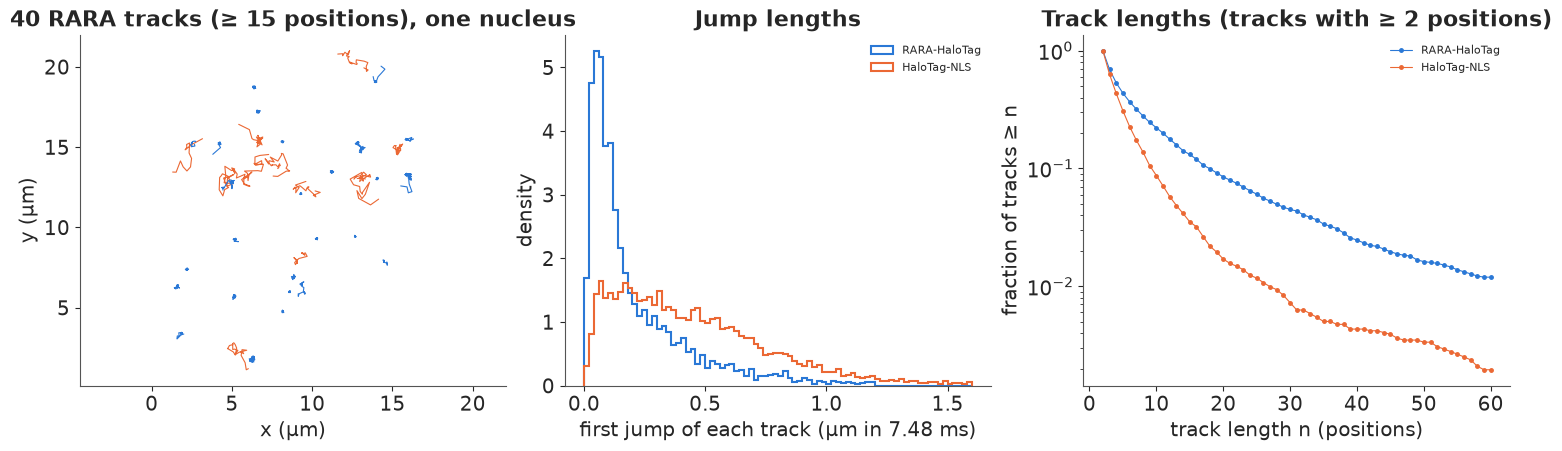

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ax = axes[0]
sel = [t for t in rara_tracks if len(t) >= 15][:40]
for t in sel:
    jumps = np.hypot(*np.diff(t, axis=0).T)
    ax.plot(t[:, 0], t[:, 1], "-", lw=0.8, color=ORANGE if np.median(jumps) > 0.15 else BLUE)
ax.set(xlabel="x (µm)", ylabel="y (µm)", title="40 RARA tracks (≥ 15 positions), one nucleus")
ax.set_aspect("equal", adjustable="datalim")
ax = axes[1]
bins = np.linspace(0, 1.6, 81)
for c, col, lab in [("rara", BLUE, "RARA-HaloTag"), ("nls", ORANGE, "HaloTag-NLS")]:
    ax.hist(first_jump[c], bins=bins, density=True, histtype="step", lw=1.5, color=col, label=lab)
ax.set(xlabel="first jump of each track (µm in 7.48 ms)", ylabel="density", title="Jump lengths")
ax.legend(fontsize=8)
ax = axes[2]
for c, col, lab in [("rara", BLUE, "RARA-HaloTag"), ("nls", ORANGE, "HaloTag-NLS")]:
    L = lengths[c]
    ns = np.arange(2, 61)
    ax.plot(ns, [(L >= n).mean() for n in ns], "o-", ms=2.5, lw=0.8, color=col, label=lab)
ax.set(yscale="log", xlabel="track length n (positions)", ylabel="fraction of tracks ≥ n",
       title="Track lengths (tracks with ≥ 2 positions)")
ax.legend(fontsize=8);

The table and figure show what makes real SPT data hard. **Half or more of all tracks are single
localisations** (52% for RARA, 64% for the control) with no displacement at all, and a typical track
has 3-4 positions. The reported localisation errors are 20 nm (RARA) and 34 nm (control, whose
spots are dimmer) - the same order as a bound molecule's motion per frame. **Left:** 40 RARA tracks
of one nucleus, coloured by their median jump: compact knots (bound) and open wanderings (free).
**Middle:** RARA's first jumps have a sharp peak at about 50 nm - bound molecules, a peak made mostly
of localisation error - and a long tail; the control has no peak and a broad distribution out to
1.5 µm. **Right:** control tracks are shorter (0.6% reach 30 positions, against 5% for RARA): a fast
molecule leaves the 0.7 µm focal slice within a few frames.

One more thing hides in the printed jump ranges: no RARA jump is longer than 1.19 µm and no control
jump longer than 1.98 µm. The tracking software only links spots within a **search radius**; a
molecule that jumped further starts a new track. For the states fitted below this truncation is
negligible (a $D = 6$ µm²/s molecule jumps more than 1.2 µm in 0.06% of frames), but it would bias
any faster state.

## 5 · A population of states: bound and free (Spot-On style)

The classic analysis of such data (Spot-On, Hansen et al. 2018) treats every track as coming from
one of a few **states** with their own $D$ - "bound" and "free", perhaps a third - and estimates
the **fraction** of molecules in each. With the sine-basis likelihood this is a mixture over
whole tracks: track $i$ with modes $u_{ij}$ has

$$p(\text{track}_i) = \sum_s w_s\, p(n_i \mid s) \prod_j \mathcal N_2\big(u_{ij} \mid 0, v_j(D_s, \sigma)\big),$$

with $\sigma$ shared (an effective error, $R = 0$; the exposure profile of these movies is not in
the repository). The factor $p(n_i \mid s)$ is where the **out-of-focus bias** lives. A molecule is
lost when it bleaches, blinks or leaves the 0.7 µm focal slice, and a free molecule leaves the
slice far sooner than a bound one. So long tracks are mostly bound, and any analysis that keeps
only "good" long tracks under-counts the free state. Spot-On corrects for this with a calculated
escape probability; here we let the data speak and give each state its own per-frame survival
probability $q_s$: $p(n \mid s) = (1 - q_s)\, q_s^{\,n-2}$ for $n \ge 2$ positions. The weights
$w_s$ are then the state fractions **among tracks at their first jump**, which is what the first
jumps in the middle panel above show. To keep the model quick, only the first 20 positions of each
track enter the likelihood of the displacements (the length term uses the full length).

Priors: $\log D_s$ normal with sd 1.5 around 0.03, 0.8 (for three states) and 3 µm²/s, with the
ordered transform (no label switching); $w \sim$ Dirichlet(2, ...); $\sigma \sim$
LogNormal($\log 0.03$, 0.5); $q_s \sim$ Beta(2, 2).

In [10]:
CAP = 20


def mixture_model(tracks, lens, K, use_length=True, cap=CAP):
    z2, cc, idx = pack_tracks(tracks, cap)
    mu0 = {1: [np.log(3.0)], 2: [np.log(0.03), np.log(3.0)], 3: [np.log(0.03), np.log(0.8), np.log(3.0)]}[K]
    with pm.Model(coords={"state": np.arange(K)}) as model:
        logD = pm.Normal("logD", mu0, 1.5, dims="state",
                         transform=pm.distributions.transforms.ordered if K > 1 else None)
        w = pm.Dirichlet("w", np.full(K, 2.0), dims="state")
        sigma = pm.LogNormal("sigma", np.log(0.03), 0.5)
        pm.Deterministic("D", pt.exp(logD), dims="state")
        v = 2 * pt.exp(logD)[None] * DT + 2 * sigma**2 * (1 - cc)[:, None]           # modes x states
        lp_mode = -pt.log(2 * np.pi * v) - z2[:, None] / (2 * v)
        lp_track = pt.zeros((len(tracks), K))
        lp_track = pt.inc_subtensor(lp_track[idx], lp_mode)
        if use_length:
            q = pm.Beta("q", 2.0, 2.0, dims="state")
            lp_track = lp_track + pt.log1p(-q)[None] + (lens[:, None] - 2) * pt.log(q)[None]
        pm.Potential("lik", pt.logsumexp(pt.log(w)[None] + lp_track, axis=1).sum())
    return model


def mixture_track_loglik(idata, tracks, lens, cap=CAP, n_draws=400):
    """Per-track log-likelihood (draws x tracks) and state responsibilities, in NumPy."""
    z2, cc, idx = pack_tracks(tracks, cap)
    post = az.extract(idata, var_names=["D", "w", "sigma", "q"], num_samples=n_draws, random_seed=RANDOM_SEED)
    D, w, s, q = (post[v].values for v in ["D", "w", "sigma", "q"])
    D, w, q = D.reshape(-1, n_draws).T, w.reshape(-1, n_draws).T, q.reshape(-1, n_draws).T
    K, N = D.shape[1], len(tracks)
    ll = np.zeros((n_draws, N))
    resp = np.zeros((N, K))
    for i in range(n_draws):
        v = 2 * D[i][None] * DT + 2 * s[i] ** 2 * (1 - cc)[:, None]
        lpm = -np.log(2 * np.pi * v) - z2[:, None] / (2 * v)
        lpt = np.stack([np.bincount(idx, lpm[:, k], minlength=N) for k in range(K)], axis=1)
        lpt += np.log1p(-q[i])[None] + (lens[:, None] - 2) * np.log(q[i])[None] + np.log(w[i])[None]
        ll[i] = logsumexp(lpt, axis=1)
        resp += np.exp(lpt - ll[i][:, None]) / n_draws
    return ll, resp


def loo_from(ll, name="track"):
    tree = xr.DataTree.from_dict({
        "posterior": xr.Dataset({"dummy": (("chain", "draw"), np.zeros((1, ll.shape[0])))}),
        "log_likelihood": xr.Dataset({name: (("chain", "draw", name), ll[None])})})
    return az.loo(tree, var_name=name, pointwise=True)


lens_rara = lengths["rara"]
mix = {}
for K in (2, 3):
    mix[K] = fit(mixture_model(rara_tracks, lens_rara, K), f"RARA, {K} states")
    print(az.summary(mix[K], var_names=["D"], round_to=3).iloc[:, :4].to_string())
    print(az.summary(mix[K], var_names=["w"], round_to=3).iloc[:, :4].to_string())
    print(az.summary(mix[K], var_names=["q"], round_to=3).iloc[:, :4].to_string())
    print(az.summary(mix[K], var_names=["sigma"], round_to=4).iloc[:, :4].to_string())

RARA, 2 states: 6 s, divergences 0, max r_hat 1.003, min ESS 779
       mean     sd  eti89_lb  eti89_ub
D[0]  0.042  0.002     0.039     0.044
D[1]  4.045  0.046     3.972     4.118
       mean     sd  eti89_lb  eti89_ub
w[0]  0.466  0.009     0.452     0.480
w[1]  0.534  0.009     0.520     0.548
       mean     sd  eti89_lb  eti89_ub
q[0]  0.888  0.003     0.884     0.892
q[1]  0.814  0.004     0.807     0.820
         mean      sd  eti89_lb  eti89_ub
sigma  0.0382  0.0004    0.0376    0.0388


RARA, 3 states: 9 s, divergences 0, max r_hat 1.003, min ESS 1313
       mean     sd  eti89_lb  eti89_ub
D[0]  0.023  0.001     0.021     0.025
D[1]  0.916  0.029     0.870     0.963
D[2]  6.327  0.122     6.135     6.528
       mean     sd  eti89_lb  eti89_ub
w[0]  0.375  0.010     0.359     0.392
w[1]  0.257  0.012     0.239     0.276
w[2]  0.367  0.011     0.350     0.385
       mean     sd  eti89_lb  eti89_ub
q[0]  0.897  0.003     0.892     0.901
q[1]  0.868  0.005     0.860     0.876
q[2]  0.746  0.007     0.736     0.757
         mean      sd  eti89_lb  eti89_ub
sigma  0.0352  0.0003    0.0347    0.0357


In [11]:
ll_mix, resp_mix, loo_mix = {}, {}, {}
for K in (2, 3):
    ll_mix[K], resp_mix[K] = mixture_track_loglik(mix[K], rara_tracks, lens_rara)
    loo_mix[K] = loo_from(ll_mix[K])
    loo_mix[K].log_weights = None
print(az.compare({"2 states": loo_mix[2], "3 states": loo_mix[3]}, round_to=1).to_string())
print(f"Pareto k > 0.7: 2 states {(loo_mix[2].pareto_k.values > 0.7).sum()}, 3 states {(loo_mix[3].pareto_k.values > 0.7).sum()}")

          rank  elpd_diff    dse  p_worse diag_diff diag_elpd     p     elpd      se  weight
3 states     0        0.0    0.0      NaN                      38.5  22092.6  1026.0     0.8
2 states     1    -2452.5  161.1      1.0                      31.1  19640.1  1009.8     0.2
Pareto k > 0.7: 2 states 0, 3 states 0


Both fits sample cleanly (no divergences, r_hat ≤ 1.005) in about 10 s for 3,770 tracks. The two-state
model finds a bound state at $D = 0.042$ µm²/s and a free one at 4.0 µm²/s, with 47% of tracks
starting bound. The three-state model splits them: **bound** at 0.023 µm²/s (38% of tracks), a
**slow** state at 0.92 µm²/s (26%) and a **fast** state at 6.3 µm²/s (37%). Analyses of nuclear
factors with Spot-On or saSPT often report such an intermediate state and attribute it to transient,
non-specific interactions with chromatin or to diffusion within dense regions. The three-state model is better by
about 2,450 in elpd (se of the difference 160) - an enormous margin - and no Pareto $k$ exceeds 0.7
(a per-track LOO: all displacements of a track are left out together). The per-frame survival
probabilities differ as expected: 0.90 for bound, 0.87 slow, 0.75 fast. The effective $\sigma$ is
35-38 nm, well above the reported 20 nm: part of the bound molecules' motion is not Brownian (section 7).

### Checks: the jumps and the track lengths

The model makes two predictions we can hold against the data. The **first jump** of each track
(the one jump every track has, so no weighting by track length) should follow the mixture of
2-D Gaussian jump-length densities $\sum_s w_s\, \frac{r}{v_s} e^{-r^2/2v_s}$ with $v_s = 2D_s\Delta t
+ 2\sigma^2$; and the **track lengths** should follow the mixture of geometric laws.

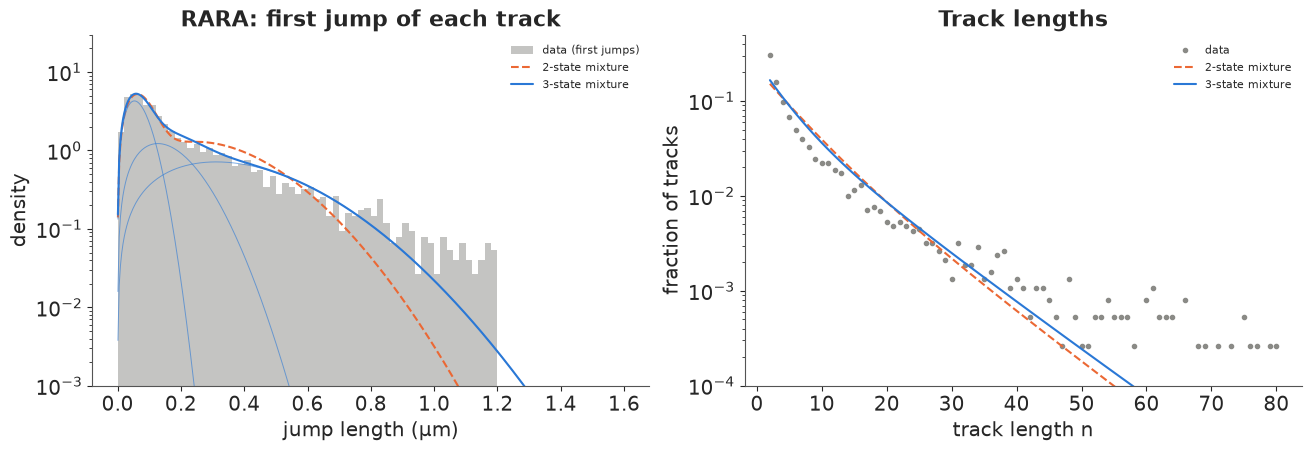

In [12]:
def post_mean(idata, v):
    return idata.posterior[v].mean(("chain", "draw")).values


fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
rr = np.linspace(0.001, 1.6, 400)
ax.hist(first_jump["rara"], bins=np.linspace(0, 1.6, 81), density=True, color=GREY, alpha=0.5, label="data (first jumps)")
for K, col, ls in [(2, ORANGE, "--"), (3, BLUE, "-")]:
    D_, w_, s_ = post_mean(mix[K], "D"), post_mean(mix[K], "w"), float(post_mean(mix[K], "sigma"))
    vv = 2 * D_ * DT + 2 * s_**2
    dens = (w_[:, None] * rr / vv[:, None] * np.exp(-rr**2 / (2 * vv[:, None])))
    ax.plot(rr, dens.sum(0), color=col, ls=ls, label=f"{K}-state mixture")
    if K == 3:
        for k in range(K):
            ax.plot(rr, dens[k], color=col, lw=0.7, alpha=0.6)
ax.set(xlabel="jump length (µm)", ylabel="density", title="RARA: first jump of each track", yscale="log", ylim=(1e-3, 30))
ax.legend(fontsize=8)
ax = axes[1]
ns = np.arange(2, 81)
emp = np.array([(lens_rara == n).mean() for n in ns])
ax.plot(ns, emp, "o", ms=3, color=GREY, label="data")
for K, col, ls in [(2, ORANGE, "--"), (3, BLUE, "-")]:
    w_, q_ = post_mean(mix[K], "w"), post_mean(mix[K], "q")
    pn = (w_[:, None] * (1 - q_[:, None]) * q_[:, None] ** (ns[None] - 2))
    ax.plot(ns, pn.sum(0), color=col, ls=ls, label=f"{K}-state mixture")
ax.set(yscale="log", xlabel="track length n", ylabel="fraction of tracks", title="Track lengths", ylim=(1e-4, 0.5))
ax.legend(fontsize=8);

**Left** (log scale): the three-state mixture follows the first-jump distribution through its peak,
its shoulder at 0.1-0.3 µm (which the two-state model misses) and most of its tail; beyond about
0.9 µm the data are heavier than either model, and they end at the tracker's 1.2 µm search radius.
Three fixed $D$'s are a coarse description of what may be a continuum of mobilities: letting each
state's $D$ vary between molecules (a log-normal spread per state, integrated out on a
quadrature grid) gave a posterior with r_hat 1.5-2.4 in a prototype - the states overlap and
trade places - which is the motivation for the non-parametric "state arrays" of saSPT. **Right:**
the geometric track-length laws capture lengths from 3 to about 35 positions. The data have more
two-position tracks than predicted (30% against 17%; short fragments from blinking or mis-linking)
and a heavier tail of very long tracks, i.e. survival is not quite constant.

### The out-of-focus bias

What would we conclude from the "good" tracks only? A common practice is to keep tracks with at
least 10 positions and ignore how long tracks are. We refit the 3-state model that way and
compare the state fractions.

In [13]:
long_idx = np.flatnonzero(lens_rara >= 10)
mix_long = fit(mixture_model([rara_tracks[i] for i in long_idx], lens_rara[long_idx], 3, use_length=False),
               "RARA, 3 states, tracks >= 10 positions, no length term")
frac = pd.DataFrame({
    "all tracks + length model": post_mean(mix[3], "w"),
    "tracks >= 10 positions only": post_mean(mix_long, "w"),
    "D (all tracks)": post_mean(mix[3], "D"),
    "D (long tracks)": post_mean(mix_long, "D")},
    index=["bound", "slow", "fast"])
print(frac.round(3).to_string())
q3 = post_mean(mix[3], "q")
print("mean number of displacements per track, by state:", np.round(1 / (1 - q3), 1))

RARA, 3 states, tracks >= 10 positions, no length term: 5 s, divergences 0, max r_hat 1.002, min ESS 974
       all tracks + length model  tracks >= 10 positions only  D (all tracks)  D (long tracks)
bound                      0.375                        0.480           0.023            0.021
slow                       0.257                        0.270           0.916            0.733
fast                       0.367                        0.249           6.327            4.753
mean number of displacements per track, by state: [9.7 7.6 3.9]


Keeping only tracks with at least 10 positions raises the bound fraction from 38% to 48% and cuts the
fast fraction from 37% to 25%; the fast state's $D$ also drops from 6.3 to 4.8 µm²/s, because the
fastest molecules are the first to leave the focal slice. The survival probabilities explain why: a
bound molecule gives on average 9.7 displacements before it is lost, a fast one 3.9. Any
selection on track length is a selection on the state. Modelling the loss (here a per-state
geometric law; in Spot-On a calculated escape probability from a slice of known depth) lets all
tracks count. The weights are still fractions of *tracks*, not of molecules in the nucleus: a free
molecule also enters the focal slice more often than a bound one. Converting one into the other
needs a model of the axial motion, which is what Spot-On's defocalisation correction does.

### A hierarchy across cells: the free control

The HaloTag-NLS control comes from eleven nuclei, some with a few hundred tracks, some with
a thousand. Cells differ (nuclear crowding, expression level, focus), so each nucleus $c$ gets its
own free-state $D_c$ and bound fraction $f_c$, partially pooled:
$\log D_c \sim \mathcal N(\mu_D, \tau_D)$, $\operatorname{logit} f_c \sim \mathcal N(\mu_f, \tau_f)$
(non-centred), with a shared $\sigma$, a shared immobile-state $D_0$ and per-state survival. Two
states suffice for a control: anything "bound" here is an immobile artefact or a
non-specific interaction, and its fraction should be small.

In [14]:
nls_cells = np.unique(nls_region)
cell_idx = pd.Index(nls_cells).get_indexer(nls_region)
lens_nls = lengths["nls"]
z2n, ccn, idxn = pack_tracks(nls_tracks, CAP)
with pm.Model(coords={"cell": nls_cells, "state": ["immobile", "free"]}) as nls_model:
    logD0 = pm.Normal("logD_immobile", np.log(0.03), 1.5)
    mu_D = pm.Normal("mu_logD_free", np.log(5.0), 1.0)
    tau_D = pm.HalfNormal("tau_logD", 0.3)
    logD_c = pm.Deterministic("logD_free", mu_D + tau_D * pm.Normal("zD", 0, 1, dims="cell"), dims="cell")
    mu_f = pm.Normal("mu_logit_f", -2.0, 1.5)
    tau_f = pm.HalfNormal("tau_logit_f", 1.0)
    f_c = pm.Deterministic("f_immobile", pm.math.sigmoid(mu_f + tau_f * pm.Normal("zf", 0, 1, dims="cell")), dims="cell")
    sigma_n = pm.LogNormal("sigma", np.log(0.03), 0.5)
    q_n = pm.Beta("q", 2.0, 2.0, dims="state")
    pm.Deterministic("D_free", pt.exp(logD_c), dims="cell")
    pm.Deterministic("D_free_pop", pt.exp(mu_D))
    D_trk = pt.stack([pt.exp(logD0) + 0 * logD_c[cell_idx], pt.exp(logD_c[cell_idx])], axis=1)   # tracks x 2
    v = 2 * D_trk[idxn] * DT + 2 * sigma_n**2 * (1 - ccn)[:, None]
    lpm = -pt.log(2 * np.pi * v) - z2n[:, None] / (2 * v)
    lpt = pt.inc_subtensor(pt.zeros((len(nls_tracks), 2))[idxn], lpm)
    lpt = lpt + pt.log1p(-q_n)[None] + (lens_nls[:, None] - 2) * pt.log(q_n)[None]
    logw = pt.stack([pt.log(f_c[cell_idx]), pt.log1p(-f_c[cell_idx])], axis=1)
    pm.Potential("lik", pt.logsumexp(logw + lpt, axis=1).sum())
idata_nls = fit(nls_model, "NLS, 2 states, 11 cells", target_accept=0.9,
                var_names=["logD_immobile", "mu_logD_free", "tau_logD", "mu_logit_f", "tau_logit_f", "sigma",
                           "q", "D_free", "D_free_pop", "f_immobile", "logD_free"])
print(az.summary(idata_nls, var_names=["D_free_pop", "tau_logD", "tau_logit_f", "sigma", "q"], round_to=3).iloc[:, :4].to_string())
print(f"immobile D: {np.exp(post_mean(idata_nls, 'logD_immobile')):.3f} µm²/s")

NLS, 2 states, 11 cells: 34 s, divergences 0, max r_hat 1.004, min ESS 391
               mean     sd  eti89_lb  eti89_ub
D_free_pop   10.216  0.694     9.125    11.336
tau_logD      0.208  0.056     0.139     0.308
tau_logit_f   0.575  0.157     0.373     0.860
sigma         0.045  0.001     0.044     0.047
q[immobile]   0.871  0.005     0.863     0.879
q[free]       0.700  0.003     0.695     0.705
immobile D: 0.143 µm²/s


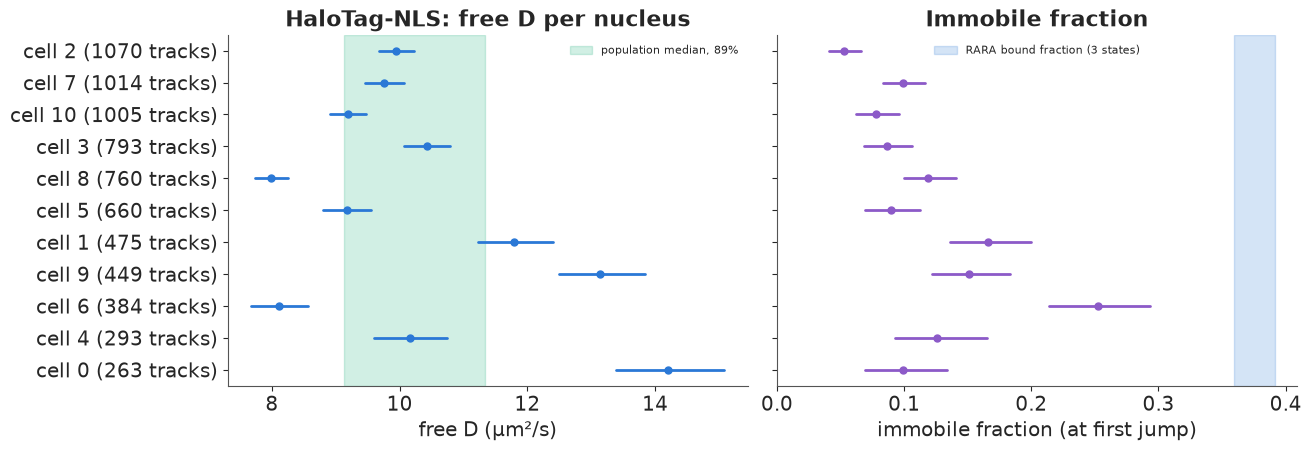

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
n_cell = np.bincount(cell_idx)
order = np.argsort(n_cell)
Dc = idata_nls.posterior["D_free"]
fc = idata_nls.posterior["f_immobile"]
ax = axes[0]
for pos, c in enumerate(order):
    q_ = np.quantile(Dc.isel(cell=c).values, [0.055, 0.5, 0.945])
    ax.plot([q_[0], q_[2]], [pos, pos], color=BLUE, lw=2)
    ax.plot(q_[1], pos, "o", color=BLUE, ms=5)
pop = np.quantile(idata_nls.posterior["D_free_pop"].values, [0.055, 0.945])
ax.axvspan(*pop, color=AQUA, alpha=0.2, label="population median, 89%")
ax.set_yticks(range(len(order)), [f"cell {nls_cells[c]} ({n_cell[c]} tracks)" for c in order])
ax.set(xlabel="free D (µm²/s)", title="HaloTag-NLS: free D per nucleus")
ax.legend(fontsize=8)
ax = axes[1]
for pos, c in enumerate(order):
    q_ = np.quantile(fc.isel(cell=c).values, [0.055, 0.5, 0.945])
    ax.plot([q_[0], q_[2]], [pos, pos], color=PURPLE, lw=2)
    ax.plot(q_[1], pos, "o", color=PURPLE, ms=5)
rara_bound = mix[3].posterior["w"].isel(state=0).values.ravel()
ax.axvspan(*np.quantile(rara_bound, [0.055, 0.945]), color=BLUE, alpha=0.2, label="RARA bound fraction (3 states)")
ax.set_yticks(range(len(order)), [""] * len(order))
ax.set(xlabel="immobile fraction (at first jump)", title="Immobile fraction", xlim=(0, None))
ax.legend(fontsize=8);

The control behaves as a control should: the free state dominates, with a population median $D$ of
about 10 µm²/s (89%: 9.1-11.3) - faster than RARA's fast state, as expected for the smaller,
non-binding HaloTag-NLS - and a small immobile fraction (5-25% by nucleus, against 38% bound for
RARA). The immobile state's $D$ is 0.14 µm²/s, six times RARA's bound state: whatever it is
(aggregates, nuclear-envelope sticking, mis-linked tracks), it is not chromatin binding. The
**hierarchy** has little to shrink - every nucleus has hundreds of tracks - but it answers a different
question: between-nucleus variation is real and large. The sd of $\log D$ between nuclei is about
0.2 (89%: 0.14-0.31), so free $D$ ranges from 8 to 14 µm²/s across cells while each cell's own
interval is only ±3-6%. Pooling all tracks as if from one cell would report a $D$ ten times more precise
than the next experiment can reproduce. (The control's effective $\sigma$, 45 nm, is again above
its reported 34 nm.)

## 6 · Switching inside a track: a hidden Markov model that knows about localisation error

The mixture gives every track one state. But molecules bind and unbind *during* a track: a jump
of a free molecule, a few frames of stillness, another jump. A **hidden Markov model** (E24) lets
the state $s_k$ of each displacement follow a Markov chain with transition matrix $\Gamma$, and
the forward algorithm sums over all $K^{n}$ state paths.

E24's forward algorithm needs emissions that are **independent given the states**. Here they are
not: $\Delta_k$ and $\Delta_{k+1}$ share the error $e_{k+1}$. Tools such as vbSPT (Persson et al.
2013) ignore this and use $\Delta_k \mid s_k \sim \mathcal N(0, 2D_{s_k}\Delta t + 2\sigma^2)$. We
will see what that costs. The exact alternative writes the track as a **switching linear-Gaussian
model** in the current error: $\Delta_k = w_k + e_{k+1} - e_k$, $w_k \sim \mathcal N(0,
2D_{s_k}\Delta t)$, $e_k \sim \mathcal N(0, \sigma^2)$. For a fixed state path a Kalman filter on $e$
is exact; summed over paths, the filter's Gaussian becomes a mixture with $K^k$ components.
The standard remedy is **GPB1** (generalised pseudo-Bayes; Bar-Shalom & Li): carry, for each current
state $i$, the forward probability $\alpha_k(i)$ and one Gaussian $\mathcal N(m_i, P_i)$ for the
current error; at every step,

1. for each previous state $j$ and new state $i$: predict $\Delta_k \sim \mathcal N(-m_j,\, 2D_i\Delta t + \sigma^2 + P_j)$
   , score it, and update the error $e_{k+1} \mid \Delta_k$ is Gaussian with gain
   ($\sigma^2 / V_{ij}$);
2. $\alpha_{k+1}(i) = \sum_j \alpha_k(j)\,\Gamma_{ji}\,\text{score}_{ij}$ (the usual forward step);
3. collapse the $K$ Gaussians arriving in state $i$ into one by moment matching.

With one state this *is* the Kalman filter, so it is exact (checked below against the
sine-basis likelihood); with several it is an approximation that is excellent when states
persist for several frames. It runs in a `pytensor.scan` over time, vectorised over tracks
(padded, with a mask that freezes a finished track), with the transition matrix, $D$'s and
$\sigma$ passed as `non_sequences` (closing over model variables inside a scan fails at
gradient time).

In [16]:
def gpb_forward_np(d, mask, D, sigma, logG, logpi, dt=DT):
    """NumPy GPB1 forward filter. d: (T, N, 2) displacements, mask (T, N).
    Returns per-track log-likelihood and filtered state probabilities (T, N, K)."""
    T, N, _ = d.shape
    K, s2 = len(D), sigma**2
    la = np.broadcast_to(logpi, (N, K)).copy()
    m, P = np.zeros((N, K, 2)), np.full((N, K), s2)
    filt = np.zeros((T, N, K))
    for k in range(T):
        V = 2 * D[None, None, :] * dt + s2 + P[:, :, None]                 # N x prev j x new i
        r = d[k][:, None, None, :] + m[:, :, None, :]
        a = la[:, :, None] + logG[None] - np.log(2 * np.pi * V) - (r**2).sum(-1) / (2 * V)
        la_new = logsumexp(a, axis=1)
        wgt = np.exp(a - la_new[:, None, :])
        mij, Pij = (s2 / V)[..., None] * r, s2 - s2**2 / V
        m_new = (wgt[..., None] * mij).sum(1)
        P_new = (wgt * (Pij + ((mij - m_new[:, None]) ** 2).mean(-1))).sum(1)
        ok = mask[k][:, None]
        la, m, P = np.where(ok, la_new, la), np.where(ok[..., None], m_new, m), np.where(ok, P_new, P)
        filt[k] = np.exp(la - logsumexp(la, axis=1, keepdims=True))
    return logsumexp(la, axis=1), filt


def gpb_loglik_pt(d, mask, D, sigma, logG, logpi):
    """The same filter in PyTensor (scan over time, vectorised over tracks)."""
    s2 = sigma**2
    N, K = d.shape[1], D.shape[0]

    def step(dk, ok, la, m, P, D, s2, logG):
        V = 2 * D[None, None, :] * DT + s2 + P[:, :, None]
        r = dk[:, None, None, :] + m[:, :, None, :]
        a = la[:, :, None] + logG[None] - pt.log(2 * np.pi * V) - (r**2).sum(-1) / (2 * V)
        la_new = pt.logsumexp(a, axis=1)
        wgt = pt.exp(a - la_new[:, None, :])
        mij, Pij = (s2 / V)[..., None] * r, s2 - s2**2 / V
        m_new = (wgt[..., None] * mij).sum(1)
        P_new = (wgt * (Pij + ((mij - m_new[:, None]) ** 2).mean(-1))).sum(1)
        return (pt.switch(ok[:, None], la_new, la), pt.switch(ok[:, None, None], m_new, m),
                pt.switch(ok[:, None], P_new, P))

    la, _, _ = pytensor.scan(
        step, sequences=[pt.as_tensor(d), pt.as_tensor(mask.astype("int8"))],
        outputs_info=[pt.zeros((N, K)) + logpi[None], pt.zeros((N, K, 2)), pt.zeros((N, K)) + s2],
        non_sequences=[D, s2, logG], return_updates=False)
    return pt.logsumexp(la[-1], axis=1)


def indep_loglik_pt(d, mask, D, sigma, G, pi):
    """Textbook HMM: displacements independent given the state, variance 2 D dt + 2 sigma^2."""
    var = 2 * D * DT + 2 * sigma**2
    lE = -pt.log(2 * np.pi * var)[None, None] - (d**2).sum(-1)[..., None] / (2 * var)[None, None]

    def step(le, ok, la, G):
        return pt.switch(ok[:, None], pt.logsumexp(la[:, :, None] + pt.log(G)[None], axis=1) + le, la)

    la = pytensor.scan(step, sequences=[lE[1:], pt.as_tensor(mask[1:].astype("int8"))],
                       outputs_info=[pt.log(pi)[None] + lE[0]], non_sequences=[G], return_updates=False)
    return pt.logsumexp(la[-1], axis=1)


# exactness check with one state against the sine basis
t_chk = simulate_track(25, 0.2, 0.03, rng, exposure=0.03)
d_chk = np.diff(t_chk, axis=0)
Qc, cc_chk = dst_basis(len(d_chk))
exact = stats.norm(0, np.sqrt(mode_var(0.2, 0.03, cc_chk))[:, None]).logpdf(Qc @ d_chk).sum()
gpb1 = gpb_forward_np(d_chk[:, None], np.ones((len(d_chk), 1), bool), np.array([0.2]), 0.03,
                      np.zeros((1, 1)), np.zeros(1))[0][0]
print(f"one state: sine-basis {exact:.10f}, GPB1 filter {gpb1:.10f}")

one state: sine-basis 61.8326771915, GPB1 filter 61.8326771915


### Does it work? A simulation with known switching

100 tracks of 40 positions switch between bound ($D = 0.03$) and free ($D = 3$ µm²/s) with a 5%
chance per frame of leaving either state (a mean stay of 20 frames, 0.15 s), $\sigma = 35$ nm.
We fit both HMMs with the same priors: ordered $\log D$ as before, $\sigma$ as before, and a
sticky Dirichlet(21, 1) row for each state's transition probabilities (prior mean 95% stay).

In [17]:
def hmm_model(d, mask, K=2, exact=True):
    mu0 = [np.log(0.03), np.log(3.0)] if K == 2 else [np.log(0.02), np.log(0.8), np.log(5.0)]
    with pm.Model(coords={"state": np.arange(K), "to": np.arange(K)}) as model:
        logD = pm.Normal("logD", mu0, 1.5, dims="state", transform=pm.distributions.transforms.ordered)
        sigma = pm.LogNormal("sigma", np.log(0.03), 0.5)
        G = pm.Dirichlet("Gamma", a=np.eye(K) * 20 + 1, dims=("state", "to"))
        D = pm.Deterministic("D", pt.exp(logD), dims="state")
        A = pt.concatenate([(pt.eye(K) - G).T, pt.ones((1, K))], axis=0)     # stationary distribution
        pi = pt.linalg.solve(A.T @ A, A.T @ np.r_[np.zeros(K), 1.0])
        ll = gpb_loglik_pt(d, mask, D, sigma, pt.log(G), pt.log(pi)) if exact else indep_loglik_pt(d, mask, D, sigma, G, pi)
        pm.Potential("lik", ll.sum())
    return model


def simulate_switching(n, D, sigma, Gamma, rng):
    pi = np.linalg.lstsq(np.vstack([(np.eye(len(D)) - Gamma).T, np.ones(len(D))]), np.r_[np.zeros(len(D)), 1], rcond=None)[0]
    s = np.zeros(n - 1, int)
    s[0] = rng.choice(len(D), p=pi)
    for k in range(1, n - 1):
        s[k] = rng.choice(len(D), p=Gamma[s[k - 1]])
    steps = rng.normal(0, 1, (n - 1, 2)) * np.sqrt(2 * D[s] * DT)[:, None]
    return np.vstack([np.zeros(2), np.cumsum(steps, 0)]) + rng.normal(0, sigma, (n, 2)), s


rng6 = np.random.default_rng(6)
D_sw, sig_sw, G_sw = np.array([0.03, 3.0]), 0.035, np.array([[0.95, 0.05], [0.05, 0.95]])
sw = [simulate_switching(40, D_sw, sig_sw, G_sw, rng6) for _ in range(100)]
d_sw = np.stack([np.diff(x, axis=0) for x, _ in sw], axis=1)
mask_sw = np.ones(d_sw.shape[:2], bool)
s_sw = np.stack([s for _, s in sw], axis=1)
hmm_sim = {}
for exact, lab in [(True, "GPB1 (error-aware)"), (False, "independent emissions")]:
    hmm_sim[lab] = fit(hmm_model(d_sw, mask_sw, exact=exact), f"simulated switching, {lab}", compile_kwargs=JAX)
    print(az.summary(hmm_sim[lab], var_names=["D", "sigma"], round_to=4).iloc[:, :4].to_string())

simulated switching, GPB1 (error-aware): 17 s, divergences 0, max r_hat 1.004, min ESS 836
         mean      sd  eti89_lb  eti89_ub
D[0]   0.0345  0.0026    0.0305    0.0389
D[1]   3.1060  0.0756    2.9851    3.2277
sigma  0.0346  0.0007    0.0336    0.0357


simulated switching, independent emissions: 33 s, divergences 0, max r_hat 1.013, min ESS 285
         mean      sd  eti89_lb  eti89_ub
D[0]   0.0585  0.0511    0.0039    0.1551
D[1]   3.1303  0.0920    2.9861    3.2812
sigma  0.0310  0.0070    0.0171    0.0378


The two fits agree on the free state and on the transition probabilities, but not on the bound state:

- The **error-aware** GPB1 model recovers $\sigma$ = 34.6 nm (89%: 33.6-35.7; truth 35) and bound
  $D$ = 0.035 µm²/s (0.031-0.039; truth 0.03, just below the interval - a small bias from the
  moment-matching collapse or chance). It sampled in about 10 s with the JAX backend.
- The **textbook** HMM, which ignores the correlation, can only learn $2D\Delta t + 2\sigma^2$ for the bound
  state: bound $D$ spans 0.004-0.16 µm²/s (a factor of 40) and $\sigma$ 17-38 nm. The information that
  separates them is the negative correlation between successive displacements, which that model
  throws away. Its r_hat (1.013) and ESS (285) show the ridge too.

Both classify the steps equally well (98% correct): which state a step is in shows in the jump size,
not in the correlations. So the independent-emission HMM is fine for segmenting tracks and poor for
measuring the bound state's mobility - and it is the bound state's mobility that reveals chromatin
dynamics (section 7).

### Which state, when? Smoothed state probabilities

The forward pass gives $p(s_k \mid \Delta_{1:k})$. For $p(s_k \mid \text{whole track})$ we combine it with
the same filter run **backwards in time** (the model is time-reversible when the chain starts in its
stationary distribution): $p(s_k \mid \text{all}) \propto p(s_k \mid \Delta_{1:k})\, p(s_k \mid
\Delta_{k+1:n}) / \pi(s_k)$ - the **two-filter smoother**, approximate here because past and future
also share the error $e_{k+1}$. We average it over 40 posterior draws.

state accuracy (P(free) > 0.5): GPB1 0.977, independent 0.976


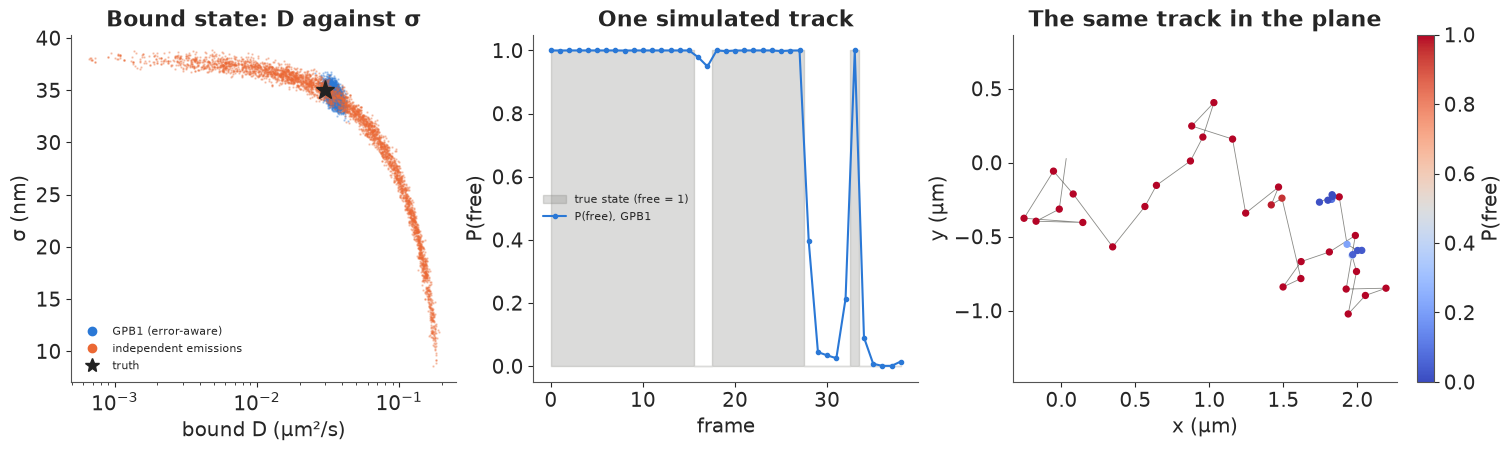

In [18]:
def smoothed_probs(idata, d, mask, n_draws=40):
    post = az.extract(idata, var_names=["D", "sigma", "Gamma"], num_samples=n_draws, random_seed=RANDOM_SEED)
    out = 0.0
    for i in range(n_draws):
        D_ = post["D"].values[:, i]
        s_ = float(post["sigma"].values[i])
        G_ = post["Gamma"].values[..., i]
        K = len(D_)
        pi_ = np.linalg.lstsq(np.vstack([(np.eye(K) - G_).T, np.ones(K)]), np.r_[np.zeros(K), 1], rcond=None)[0]
        _, fw = gpb_forward_np(d, mask, D_, s_, np.log(G_), np.log(pi_))
        # backward: reverse each track within its own length so that padding stays at the end
        n_i = mask.sum(0)
        d_rev = np.zeros_like(d)
        for j, nn in enumerate(n_i):
            d_rev[:nn, j] = d[:nn, j][::-1]
        G_rev = G_.T * pi_[None, :] / pi_[:, None]                      # P(s_k = j | s_k+1 = i)
        _, bw_rev = gpb_forward_np(d_rev, mask, D_, s_, np.log(G_rev), np.log(pi_))
        bw = np.broadcast_to(pi_, fw.shape).copy()                     # padding: prior (unused)
        for j, nn in enumerate(n_i):
            b = bw_rev[:nn, j][::-1]                                     # p(s_k | d_k..d_n)
            bw[:nn, j] = np.vstack([b[1:] @ G_rev, pi_[None]])            # p(s_k | d_k+1..d_n)
        sm = fw * bw / pi_
        out = out + sm / sm.sum(-1, keepdims=True) / n_draws
    return out


p_sw = smoothed_probs(hmm_sim["GPB1 (error-aware)"], d_sw, mask_sw)
p_sw_ind = smoothed_probs(hmm_sim["independent emissions"], d_sw, mask_sw)
print(f"state accuracy (P(free) > 0.5): GPB1 {np.mean((p_sw[..., 1] > 0.5) == s_sw):.3f}, "
      f"independent {np.mean((p_sw_ind[..., 1] > 0.5) == s_sw):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ax = axes[0]
for lab, col in [("GPB1 (error-aware)", BLUE), ("independent emissions", ORANGE)]:
    ax.plot(hmm_sim[lab].posterior["D"].isel(state=0).values.ravel(),
            hmm_sim[lab].posterior["sigma"].values.ravel() * 1e3, ".", ms=1.5, alpha=0.3, color=col, label=lab)
ax.plot(D_sw[0], sig_sw * 1e3, "*", ms=14, color=INK, label="truth")
ax.set(xscale="log", xlabel="bound D (µm²/s)", ylabel="σ (nm)", title="Bound state: D against σ")
ax.legend(handles=[plt.Line2D([], [], ls="", marker="o", color=BLUE, label="GPB1 (error-aware)"),
                   plt.Line2D([], [], ls="", marker="o", color=ORANGE, label="independent emissions"),
                   plt.Line2D([], [], ls="", marker="*", ms=10, color=INK, label="truth")], fontsize=8)
ax = axes[1]
j = int(np.argmax([np.abs(np.diff(s)).sum() for s in s_sw.T]))
k_ax = np.arange(d_sw.shape[0])
ax.fill_between(k_ax, 0, s_sw[:, j], step="mid", color=GREY, alpha=0.3, label="true state (free = 1)")
ax.plot(k_ax, p_sw[:, j, 1], "-o", ms=3, color=BLUE, label="P(free), GPB1")
ax.set(xlabel="frame", ylabel="P(free)", title="One simulated track")
ax.legend(fontsize=8)
ax = axes[2]
x_j = sw[j][0]
sc = ax.scatter(x_j[1:, 0], x_j[1:, 1], c=p_sw[:, j, 1], cmap="coolwarm", vmin=0, vmax=1, s=18, zorder=3)
ax.plot(x_j[:, 0], x_j[:, 1], color=GREY, lw=0.6)
fig.colorbar(sc, ax=ax, label="P(free)")
ax.set(xlabel="x (µm)", ylabel="y (µm)", title="The same track in the plane")
ax.set_aspect("equal", adjustable="datalim");

**Left:** the posterior draws of bound $D$ and $\sigma$: the independent-emission model's (orange)
lie along the curve $2D\Delta t + 2\sigma^2 = $ const, the GPB1 draws (blue) form a small cluster on the
truth. **Middle and right:** the smoothed probability of the free state follows the true path of one
simulated track, switching within one or two frames of each true switch; a two-frame bound visit
near frame 16 is only hinted at (P(free) dips to 0.95), and a one-frame free visit near frame 33 is
picked up.

### The RARA tracks

We fit the two-state GPB1 model to the 320 RARA tracks with at least 20 positions (first 61
positions of each: up to 60 displacements, 10,897 in all).

In [19]:
MIN_HMM, CAP_HMM = 20, 61
hmm_tracks = [t[:CAP_HMM] for t in rara_tracks if len(t) >= MIN_HMM]
hmm_err = [e[:CAP_HMM] for e in rara_err if len(e) >= MIN_HMM]
T_h = CAP_HMM - 1
d_h = np.zeros((T_h, len(hmm_tracks), 2))
mask_h = np.zeros((T_h, len(hmm_tracks)), bool)
for i, t in enumerate(hmm_tracks):
    dd = np.diff(t, axis=0)
    d_h[: len(dd), i], mask_h[: len(dd), i] = dd, True
print(f"{len(hmm_tracks)} tracks, {mask_h.sum()} displacements")
hmm_rara = fit(hmm_model(d_h, mask_h), "RARA, 2-state GPB1 HMM", compile_kwargs=JAX)
print(az.summary(hmm_rara, var_names=["D", "sigma", "Gamma"], round_to=4).iloc[:, :4].to_string())
G_post = hmm_rara.posterior["Gamma"]
dwell_ms = DT * 1e3 / (1 - G_post.sel(state=0, to=0).values.ravel())
dwell_free_ms = DT * 1e3 / (1 - G_post.sel(state=1, to=1).values.ravel())
print(f"mean stay in the bound state: {np.median(dwell_ms):.0f} ms "
      f"(89%: {np.quantile(dwell_ms, 0.055):.0f}-{np.quantile(dwell_ms, 0.945):.0f}); "
      f"free: {np.median(dwell_free_ms):.0f} ms")

320 tracks, 10897 displacements


RARA, 2-state GPB1 HMM: 54 s, divergences 0, max r_hat 1.001, min ESS 1379
               mean      sd  eti89_lb  eti89_ub
D[0]         0.0222  0.0009    0.0208    0.0236
D[1]         2.7650  0.0639    2.6636    2.8699
sigma        0.0325  0.0003    0.0320    0.0329
Gamma[0, 0]  0.9811  0.0016    0.9785    0.9835
Gamma[0, 1]  0.0189  0.0016    0.0165    0.0215
Gamma[1, 0]  0.0567  0.0052    0.0487    0.0650
Gamma[1, 1]  0.9433  0.0052    0.9350    0.9513
mean stay in the bound state: 396 ms (89%: 347-453); free: 132 ms


tracks with at least one switch: 39%; bound (P > 0.9) at every step: 43%


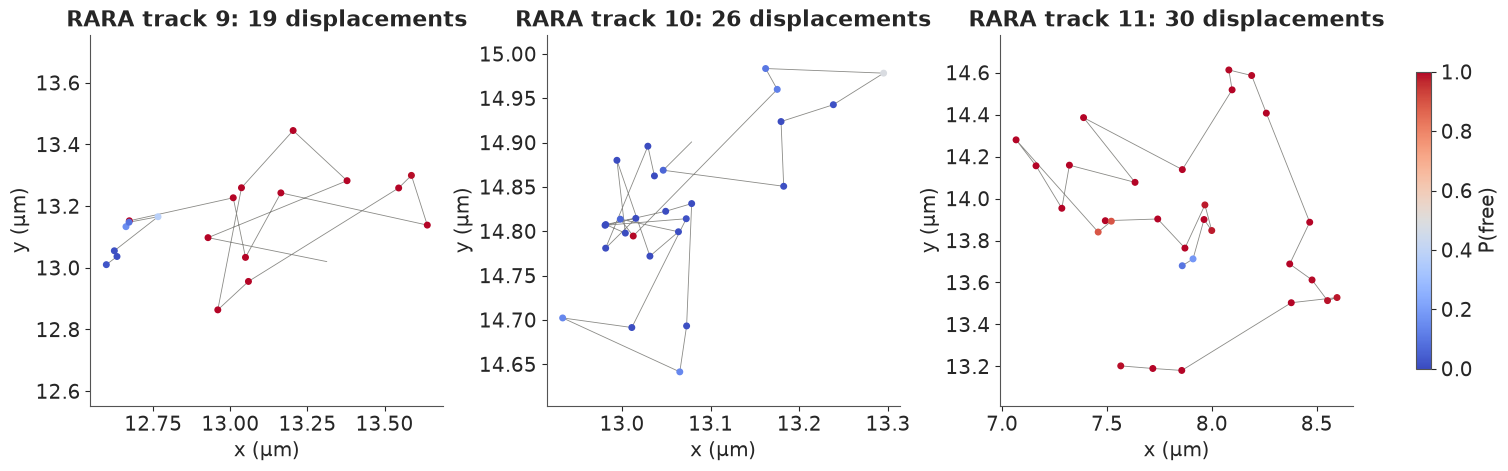

In [20]:
p_h = smoothed_probs(hmm_rara, d_h, mask_h)
n_h = mask_h.sum(0)
n_switch = np.array([np.abs(np.diff(p_h[: n_h[i], i, 1] > 0.5)).sum() for i in range(len(hmm_tracks))])
always_bound = np.array([np.all(p_h[: n_h[i], i, 0] > 0.9) for i in range(len(hmm_tracks))])
print(f"tracks with at least one switch: {np.mean(n_switch > 0):.0%}; "
      f"bound (P > 0.9) at every step: {np.mean(always_bound):.0%}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
show = np.flatnonzero(n_switch > 0)[:3]
for ax, i in zip(axes, show):
    t = hmm_tracks[i]
    sc = ax.scatter(t[1:, 0], t[1:, 1], c=p_h[: n_h[i], i, 1], cmap="coolwarm", vmin=0, vmax=1, s=16, zorder=3)
    ax.plot(t[:, 0], t[:, 1], color=GREY, lw=0.6)
    ax.set(xlabel="x (µm)", ylabel="y (µm)", title=f"RARA track {i}: {n_h[i]} displacements")
    ax.set_aspect("equal", adjustable="datalim")
fig.colorbar(sc, ax=axes, label="P(free)", shrink=0.8);

The HMM finds a bound state at 0.022 µm²/s and a free one at 2.8 µm²/s (the long tracks carry few
fast molecules, so "free" here mostly means the slow state of section 5). A bound molecule leaves the
bound state with probability 1.9% per frame: a mean stay of about 400 ms (89%: 350-450 ms) *while in
view*; the free state lasts about 130 ms. Because the forward algorithm simply stops at the end of a
track, bleaching and defocusing censor these dwell times without biasing them - under the model's
assumption that losing a molecule does not depend on how long it has been bound. Stays of
chromatin-bound transcription factors are often seconds long when measured with slow imaging
designed for that purpose (long exposures blur free molecules away); a 7.48 ms movie of short
tracks sees mainly the short, transient interactions. 39% of the long tracks switch at least once,
and 43% are confidently bound (P > 0.9) at every step. The three tracks above show typical
switches: a molecule that unbinds and leaves (track 9), a bound molecule with a few large jumps that
the model is unsure about (track 10), and a free molecule that pauses briefly (track 11). A three-state HMM is the natural next step;
with the same code it took about four minutes to sample in a prototype, beyond this notebook's
budget (exercise 2).

Note the effective error again: $\sigma$ = 32.5 nm, against a reported 16 nm for the localisations in
these long tracks (printed below). The HMM's bound state is Brownian; if the bound molecules'
displacements anticorrelate more than Brownian motion plus error allows, the model can only absorb
that with a larger $\sigma$. Section 7 tests exactly this.

## 7 · Is it anomalous? Fractional Brownian motion and fake subdiffusion

A bound transcription factor moves with its piece of chromatin, and chromatin is a polymer: its
loci are known to move **subdiffusively**, $\text{MSD} \propto \tau^\alpha$ with $\alpha < 1$. The
simplest Gaussian model with that property is **fractional Brownian motion** (fBM) with Hurst
exponent $H = \alpha/2$: per coordinate $\langle (x(t) - x(s))^2 \rangle = 2K|t-s|^\alpha$, and the
displacements are stationary with the Toeplitz covariance

$$\operatorname{Cov}(\Delta_k, \Delta_{k+l}) = K\Delta t^\alpha\big(|l+1|^\alpha - 2|l|^\alpha + |l-1|^\alpha\big) + \sigma^2 (2\,[l = 0] - [|l| = 1]).$$

For $\alpha < 1$ successive displacements anticorrelate at *every* lag (the molecule is pulled
back), for $\alpha > 1$ they correlate (superdiffusion), $\alpha = 1$ is Brownian. Localisation
error adds a lag-1 anticorrelation - which is exactly what a little subdiffusion looks like
over short tracks. This is the question of the AnDi challenge (Muñoz-Gil et al. 2021, on
*simulated* benchmark tracks): is this motion anomalous, and what is $\alpha$?

This covariance is no longer tridiagonal, so no fixed basis diagonalises it: we use a batched
Cholesky factor, one 30 × 30 matrix per track. Each track $i$ has its own $\alpha_i = 2\,\text{logit}^{-1}(\mu_\alpha + \tau_\alpha z_i)$ 
(partial pooling, $\alpha \in (0, 2)$) and its own amplitude, which we
parameterise by the MSD at lag 6 frames, $2K(6\Delta t)^\alpha$, not by $K$: $K$ and $\alpha$
trade off strongly (a change in $\alpha$ rotates the MSD line about $\tau = 1$ s, far outside the
data), and the lag-6 amplitude decorrelates them (this cut the sampling time by 2-3x in a
prototype). 

Priors: $\mu_\alpha \sim \mathcal N(0, 1)$ (so $\alpha_{\text{pop}}$ is centred on 1),
$\tau_\alpha \sim$ HalfNormal(0.5); the amplitudes are pooled too, log $\text{MSD}_6 \sim \mathcal N(\mu_m, \tau_m)$
with $\mu_m \sim \mathcal N(\log(12 \cdot 0.03\,\Delta t), 1.5)$ and $\tau_m \sim$ HalfNormal(1) (why, below); $\sigma$
as before. First the trap, on 30 simulated **Brownian** tracks ($D = 0.02$ µm²/s, $\sigma = 30$ nm,
31 positions): fit fBM without and with the error term.

In [21]:
M_F = 30
LAG = np.abs(np.subtract.outer(np.arange(M_F), np.arange(M_F))).astype(float)
# log|l+1|, log|l|, log|l-1| with log 0 floored: x**a = exp(a log x) then has a finite gradient
# in a at x = 0 (0**a differentiates to 0 * log 0 = NaN)
LOGS = [np.log(np.maximum(np.abs(LAG + k), 1e-300)) for k in (1, 0, -1)]
LREF = 6


def fbm_model(d, with_error=True, sigma_prior=(np.log(0.03), 0.5)):
    """d: (tracks, M_F, 2) displacements."""
    N = d.shape[0]
    with pm.Model(coords={"track": np.arange(N)}) as model:
        mu_a = pm.Normal("mu_alpha", 0.0, 1.0)
        tau_a = pm.HalfNormal("tau_alpha", 0.5)
        alpha = pm.Deterministic("alpha", 2 * pm.math.sigmoid(mu_a + tau_a * pm.Normal("z", 0, 1, dims="track")), dims="track")
        pm.Deterministic("alpha_pop", 2 * pm.math.sigmoid(mu_a))
        mu_m = pm.Normal("mu_log_msd6", np.log(2 * 0.03 * LREF * DT), 1.5)
        tau_m = pm.HalfNormal("tau_log_msd6", 1.0)
        log_msd6 = pm.Deterministic("log_msd6", mu_m + tau_m * pm.Normal("z_m", 0, 1, dims="track"), dims="track")
        K = pt.exp(log_msd6 - np.log(2) - alpha * np.log(LREF * DT))
        s2 = pm.LogNormal("sigma", *sigma_prior) ** 2 if with_error else 0.0
        a = alpha[:, None, None]
        C = K[:, None, None] * DT**a * (pt.exp(a * LOGS[0]) - 2 * pt.exp(a * LOGS[1]) + pt.exp(a * LOGS[2]))
        C = C + s2 * (2 * (LAG == 0) - (LAG == 1))[None] + 1e-10 * np.eye(M_F)[None]
        L = pt.linalg.cholesky(C)
        zz = pt.linalg.solve_triangular(L, d, lower=True, b_ndim=2)                # (N, M_F, 2)
        logdet = pt.log(pt.diagonal(L, axis1=1, axis2=2)).sum()
        pm.Potential("lik", -0.5 * (zz**2).sum() - 2 * logdet - N * M_F * np.log(2 * np.pi))
    return model


rng7 = np.random.default_rng(7)
x_bm = np.cumsum(rng7.normal(0, np.sqrt(2 * 0.02 * DT), (30, M_F + 1, 2)), axis=1) + rng7.normal(0, 0.03, (30, M_F + 1, 2))
d_bm = np.diff(x_bm, axis=1)
fbm_sim = {}
for we, lab in [(False, "fBM, no error term"), (True, "fBM + localisation error")]:
    fbm_sim[lab] = fit(fbm_model(d_bm, we), f"Brownian simulation, {lab}", compile_kwargs=JAX, draws=500)
    print(az.summary(fbm_sim[lab], var_names=["alpha_pop", "tau_alpha"] + (["sigma"] if we else []),
                     round_to=3).iloc[:, :4].to_string())

Brownian simulation, fBM, no error term: 15 s, divergences 0, max r_hat 1.007, min ESS 336
            mean     sd  eti89_lb  eti89_ub
alpha_pop  0.369  0.024     0.330     0.409
tau_alpha  0.155  0.092     0.023     0.310


Brownian simulation, fBM + localisation error: 15 s, divergences 0, max r_hat 1.007, min ESS 740
            mean     sd  eti89_lb  eti89_ub
alpha_pop  1.050  0.111     0.865     1.225
tau_alpha  0.234  0.174     0.021     0.554
sigma      0.030  0.001     0.028     0.031


The trap works as advertised. Ignoring the error, the population exponent of these Brownian tracks is
0.37 (89%: 0.33-0.41): **confident, strong, and entirely fake subdiffusion**. The error's lag-1
anticorrelation is read as a molecule being pulled back. With the error term, $\alpha_{\text{pop}}$ =
1.05 (0.87-1.23), consistent with the truth, and $\sigma$ is recovered (30 nm).

A modelling note that cost a prototype: with an **independent** amplitude per track (log MSD$_6$
with a fixed prior instead of the hierarchy used here), the same kind of simulated Brownian data
gave $\alpha_{\text{pop}}$ near 1.1 in four of five datasets, some with 89% intervals excluding 1. With
only 30 displacements per track, a free nuisance parameter per track biases the shared shape
parameter (a Neyman-Scott-type problem). Pooling the amplitudes removed it (medians 0.87-0.97 on
three of the same datasets).

### Bound RARA molecules

Now the real question. We take the RARA tracks with at least 31 positions that the HMM of
section 6 calls bound ($P > 0.9$) at every one of their first 30 steps - long stretches of a
molecule sitting on chromatin.

In [22]:
bound_idx = [i for i, t in enumerate(hmm_tracks)
             if len(t) > M_F and np.all(p_h[:M_F, i, 0] > 0.9)]
d_bound = np.array([np.diff(hmm_tracks[i][: M_F + 1], axis=0) for i in bound_idx])
err_rms = np.sqrt(np.mean(np.concatenate([hmm_err[i][: M_F + 1] for i in bound_idx]) ** 2))
print(f"{len(d_bound)} bound tracks with {M_F} displacements; "
      f"rms of the reported localisation errors: {err_rms * 1e3:.1f} nm")
fbm_real = {}
for we, sp, lab in [(False, None, "fBM, no error term"),
                    (True, (np.log(0.03), 0.5), "fBM + localisation error"),
                    (True, (np.log(err_rms), 0.1), "fBM + error, σ prior from the reported errors")]:
    fbm_real[lab] = fit(fbm_model(d_bound, we, sp), f"RARA bound, {lab}", compile_kwargs=JAX, draws=500)
    print(az.summary(fbm_real[lab], var_names=["alpha_pop", "tau_alpha"] + (["sigma"] if we else []),
                     round_to=3).iloc[:, :4].to_string())
a_tr = fbm_real["fBM + error, σ prior from the reported errors"].posterior["alpha"]
p_sub = (a_tr < 1).mean(("chain", "draw")).values
print(f"tracks with P(alpha < 1) > 0.9: {np.mean(p_sub > 0.9):.0%}; with P(alpha > 1) > 0.9: {np.mean(p_sub < 0.1):.0%}")

84 bound tracks with 30 displacements; rms of the reported localisation errors: 16.3 nm


RARA bound, fBM, no error term: 49 s, divergences 0, max r_hat 1.010, min ESS 567
            mean     sd  eti89_lb  eti89_ub
alpha_pop  0.316  0.019     0.286     0.346
tau_alpha  0.403  0.075     0.286     0.525


RARA bound, fBM + localisation error: 35 s, divergences 0, max r_hat 1.010, min ESS 567
            mean     sd  eti89_lb  eti89_ub
alpha_pop  0.372  0.031     0.324     0.423
tau_alpha  0.456  0.085     0.324     0.599
sigma      0.012  0.002     0.009     0.015


RARA bound, fBM + error, σ prior from the reported errors: 35 s, divergences 0, max r_hat 1.008, min ESS 756
            mean     sd  eti89_lb  eti89_ub
alpha_pop  0.398  0.030     0.353     0.446
tau_alpha  0.491  0.089     0.352     0.640
sigma      0.015  0.001     0.013     0.016
tracks with P(alpha < 1) > 0.9: 100%; with P(alpha > 1) > 0.9: 0%


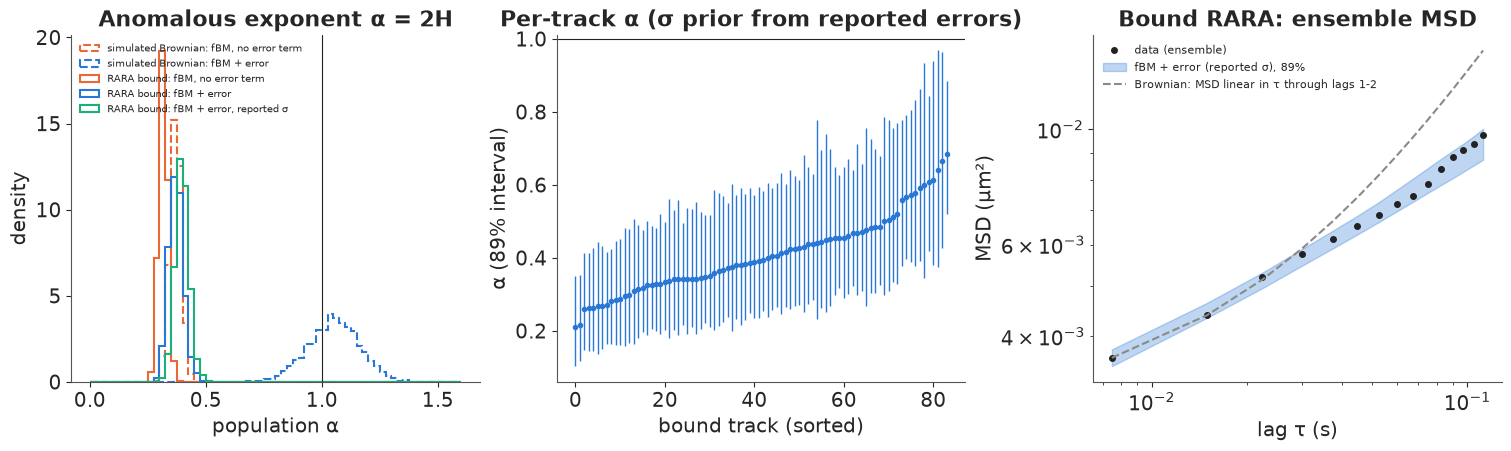

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ax = axes[0]
for src, lab, col, ls, idt in [
        ("simulated Brownian", "fBM, no error term", ORANGE, "--", fbm_sim["fBM, no error term"]),
        ("simulated Brownian", "fBM + error", BLUE, "--", fbm_sim["fBM + localisation error"]),
        ("RARA bound", "fBM, no error term", ORANGE, "-", fbm_real["fBM, no error term"]),
        ("RARA bound", "fBM + error", BLUE, "-", fbm_real["fBM + localisation error"]),
        ("RARA bound", "fBM + error, reported σ", AQUA, "-", fbm_real["fBM + error, σ prior from the reported errors"])]:
    v = idt.posterior["alpha_pop"].values.ravel()
    ax.hist(v, bins=64, range=(0, 1.6), density=True, histtype="step", lw=1.5, ls=ls, color=col, label=f"{src}: {lab}")
ax.axvline(1, color=INK, lw=0.8)
ax.set(xlabel="population α", ylabel="density", title="Anomalous exponent α = 2H")
ax.legend(fontsize=7, loc="upper left")
ax = axes[1]
med = a_tr.median(("chain", "draw")).values
qlo, qhi = a_tr.quantile([0.055, 0.945], dim=("chain", "draw")).values
o = np.argsort(med)
ax.vlines(np.arange(len(o)), qlo[o], qhi[o], color=BLUE, lw=1)
ax.plot(np.arange(len(o)), med[o], "o", ms=3, color=BLUE)
ax.axhline(1, color=INK, lw=0.8)
ax.set(xlabel="bound track (sorted)", ylabel="α (89% interval)", title="Per-track α (σ prior from reported errors)")
ax = axes[2]
lg = np.arange(1, 16)
xb = np.cumsum(np.concatenate([np.zeros((len(d_bound), 1, 2)), d_bound], axis=1), axis=1)
emp_msd = np.array([np.mean(np.sum((xb[:, k:] - xb[:, :-k]) ** 2, axis=2)) for k in lg])
ax.plot(lg * DT, emp_msd, "o", color=INK, ms=4, label="data (ensemble)")
post = az.extract(fbm_real["fBM + error, σ prior from the reported errors"], var_names=["alpha", "log_msd6", "sigma"], num_samples=300,
                  random_seed=RANDOM_SEED)
al, lm, sg = post["alpha"].values, post["log_msd6"].values, post["sigma"].values
curves = np.array([np.mean(2 * 2 * np.exp(lm[:, s])[:, None] / 2 * (lg[None] / LREF) ** al[:, s][:, None], axis=0)
                   + 4 * sg[s] ** 2 for s in range(al.shape[1])])
ax.fill_between(lg * DT, *np.quantile(curves, [0.055, 0.945], axis=0), color=BLUE, alpha=0.3, label="fBM + error (reported σ), 89%")
bm_line = emp_msd[0] + (lg - 1) * (emp_msd[1] - emp_msd[0])
ax.plot(lg * DT, bm_line, "--", color=GREY, label="Brownian: MSD linear in τ through lags 1-2")
ax.set(xscale="log", yscale="log", xlabel="lag τ (s)", ylabel="MSD (µm²)", title="Bound RARA: ensemble MSD")
ax.legend(fontsize=8);

**Left:** on the Brownian simulation (dashed) the error term moves $\alpha$ from a false 0.37 to the
truth. On the bound RARA tracks (solid, 84 tracks) it moves much less: from 0.32 without the error to
0.37 (89%: 0.32-0.42) with a free $\sigma$, and 0.40 (0.35-0.45) when $\sigma$ gets an informative prior
from the reported localisation errors (rms 16 nm; posterior 15 nm). This subdiffusion survives the
correction: **bound RARA molecules move subdiffusively with $\alpha \approx 0.4$** - consistent with the
range reported for chromatin loci in mammalian nuclei. Note that the free-$\sigma$ fit puts $\sigma$ at
12 nm, below the reported errors: $\sigma$ and $\alpha$ still trade off, and the independent calibration
of the error is what pins them down. **Middle:** every one of the 84 tracks has $P(\alpha < 1) > 0.9$,
with medians from 0.2 to 0.7 (the between-track sd on the logit scale is about 0.5): chromatin
mobility is heterogeneous. **Right:** the ensemble MSD of these tracks bends below the Brownian line
through its first two points; by 110 ms the Brownian extrapolation overshoots the data by about 60%,
and the fBM posterior follows the bend.

This also explains the effective errors of sections 5 and 6: a Brownian bound state needs
$\sigma$ = 32-38 nm to mimic the extra anticorrelation of subdiffusion, twice the reported error. The
caveats: the tracks were *selected* as bound by a Brownian HMM, which favours tracks with small,
confined motion; 30 displacements (0.22 s) cannot distinguish fBM from other subdiffusive models
(confinement in a small domain, continuous-time random walks) - the AnDi challenge's other
question; and motion blur, which we could not quantify for these movies, would add a positive
lag-1 correlation and slightly *raise* $\alpha$.

## Summary

| question | model | answer here |
|---|---|---|
| what is a track's likelihood? | Gaussian displacements, tridiagonal (MA(1)) covariance from localisation error and blur; exact and scan-free in the sine eigenbasis | checked against the dense MvNormal to 10 decimals |
| $D$ of one short track? | per-track $D$, $\sigma$ | MSD(1) overestimates bound $D$ threefold; a 4-point MSD line is negative for 13% of tracks; the likelihood is near unbiased with 91% coverage of 89% intervals |
| how many states, what fractions? | mixture over whole tracks with per-state survival | RARA: bound 0.023, slow 0.9, fast 6.3 µm²/s; 38/26/37% of tracks; 3 states beat 2 by ~2,450 elpd |
| what does selecting long tracks do? | same mixture, long tracks only | bound fraction 38% → 48%, fast 37% → 25% |
| cell-to-cell variation? | hierarchy over 11 control nuclei | free $D$ ≈ 10 µm²/s, between-cell sd ≈ 20% |
| binding and unbinding inside tracks? | HMM with a GPB1 filter that carries the error | bound stay ≈ 0.4 s in view; the textbook HMM cannot separate bound $D$ from $\sigma$ |
| is bound motion anomalous? | fBM with error, hierarchical α | α ≈ 0.4; without the error term Brownian tracks look like α ≈ 0.37 |

- **Localisation error is the main character.** It inflates naive $D$, makes MSD fits noisy,
  hides the bound state's mobility from textbook HMMs and fakes subdiffusion. The fix each time is
  the same: put the error in the likelihood, where it shows as a negative lag-1 correlation.
- **Short tracks and the frame rate set what is identifiable**: a track gives $2D\Delta t + 2\sigma^2$
  easily and the split only with length; blur and error are not separable from tracks at all.
  Independent information (reported localisation errors) is worth using as a prior.
- **What you keep decides what you find**: fast molecules leave focus first, so a state's fraction
  depends on how track loss is handled; the tracker's search radius truncates the fastest jumps.
- **Effective parameters flag misspecification**: a fitted $\sigma$ twice the reported one was the
  first sign that bound RARA is not Brownian.

## Try it yourself

1. **Motion blur.** Simulate full-frame exposure ($R = 1/6$) for a free molecule at $D = 5$
   µm²/s with $\sigma = 30$ nm, and fit it with $R = 0$. Show that the fitted $\sigma$ collapses (it
   estimates $\sigma^2 - 2DR\Delta t$, which is negative here) and that $D$ is biased; then fit with the
   correct $R$ in `mode_var`. What happens if you give $R$ its own prior?
2. **A three-state HMM.** Fit `hmm_model(d_h, mask_h, K=3)` (about four minutes). Does the slow
   state of section 5 appear inside tracks, and do molecules pass through it on the way to binding
   (compare $\Gamma_{\text{fast} \to \text{bound}}$ with $\Gamma_{\text{fast} \to \text{slow}}$)?
3. **Confinement instead of fBM.** Replace fBM by an Ornstein-Uhlenbeck (harmonically confined)
   position, $x_{k+1} = \phi x_k + \eta_k$ with $\phi = e^{-\kappa\Delta t}$, observed with error - a
   Kalman filter or its stationary Toeplitz covariance $\operatorname{Cov}(x_k, x_{k+l}) = \frac{D}{\kappa}\phi^{|l|}$
   per coordinate. Compare it with fBM on the bound RARA tracks by per-track LOO (compute the
   per-track log-likelihoods from the Cholesky factors). Which kind of subdiffusion do the data
   prefer?